In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [3]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [19]:
pain_cpt = {
    "facet_blocks": ["64490", "64493", "64491", "64492", "64495"],
    "facet_rfa": ["64633", "64634", "64635", "64636"],
    "transforaminal_esi": ["64483", "64484"],
    "interlaminar_caudal_esi": ["62320", "62321", "62322", "62323"],
    "si_joint_rfa": ["64628", "64629"],
    "vertebral_augmentation": ["22510", "22511", "22512", "22513", "22514", "22515"],
    # "pild": ["0275T"]
    # "mis": ["62287", "0275T"],
}

pain_add_ons = ["64491", "64492", "64495", "64634", "64636", "64484", "64629", "22515"]

cpt_map = {}

for category, codes in pain_cpt.items():
    for code in codes:
        if code in pain_add_ons:
            continue 

        try:
            cpt_map[int(code)] = category
            cpt_map[code] = category
        except:
            cpt_map[code] = category

In [20]:
for procedure in pain_cpt:
    print(f"{procedure}: {', '.join([p for p in pain_cpt[procedure] if p not in pain_add_ons])}")

facet_blocks: 64490, 64493
facet_rfa: 64633, 64635
transforaminal_esi: 64483
interlaminar_caudal_esi: 62320, 62321, 62322, 62323
si_joint_rfa: 64628
vertebral_augmentation: 22510, 22511, 22512, 22513, 22514


In [7]:
current_dir = os.getcwd()

In [8]:
surg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "surg_pain_cpt_processed.csv"))
nonsurg_data = pd.read_csv(os.path.join(current_dir, "processed-data", "nonsurg_pain_cpt_processed.csv"))

# Analysis

In [21]:
for df in [surg_data, nonsurg_data]:
    df['year'] = df['year'].astype(int)
    df['CPI'] = df['year'].map(cpi_map)

    assert df['CPI'].notna().all()

    # Adjusted averages
    factor = cpi_map[2023] / df['CPI']
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] * factor
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] * factor

    # Raw totals
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt']
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt']

    # Adjusted totals
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs_Spend'] * factor
    df['Tot_Pymt_adj'] = df['Tot_Pymt'] * factor

In [22]:
surg_data = surg_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]
nonsurg_data = nonsurg_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt",  "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]

In [23]:
for data in [surg_data, nonsurg_data]:
    data.loc[:, 'procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_25017/1292778166.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, 'procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [24]:
groupby_key = 'procedure'
specialty_name = ["Surgical", "Nonsurgical"]

In [42]:
def sem(x):
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))


def bootstrap_agg_price_ci(df, groupby_key, n_boot=1000, ci=95):
    records = []
    for keys, group in df.groupby([groupby_key, 'year']):
        n = len(group)
        estimates = []
        for _ in range(n_boot):
            sample = group.sample(n=n, replace=True)
            estimates.append(sample['Tot_Srvcs_Spend_adj'].sum() / sample['Tot_Srvcs'].sum())

        lower = np.percentile(estimates, (100 - ci) / 2)
        upper = np.percentile(estimates, 100 - (100 - ci) / 2)
        records.append({
            groupby_key: keys[0],
            'year': keys[1],
            'CI_lower_agg_price_adj': lower,
            'CI_upper_agg_price_adj': upper
        })

    return pd.DataFrame(records)

def summarize_utilization(df, groupby_key):
    out = (
        df
        .groupby([groupby_key, 'year'], as_index=False)
        .agg(
            Sum_Utilization=('Tot_Srvcs', 'sum'),
            Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
            Sum_Pymt=('Tot_Pymt', 'sum'),
            Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
            Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),

            # Provider-level unweighted summaries
            Mean_provider_price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
            Mean_provider_price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', sem),
            Mean_provider_pymt_adj=('Tot_Pymt_adj', 'mean'),
            Mean_provider_pymt_adj_sem=('Tot_Pymt_adj', sem),

            Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
        )
    )

    # Aggregate / utilization-weighted estimates
    out['Avg_Price_per_service'] = out['Sum_Spend'] / out['Sum_Utilization']
    out['Avg_Price_per_service_adj'] = out['Sum_Spend_adj'] / out['Sum_Utilization']
    out['Avg_Pymt_per_service'] = out['Sum_Pymt'] / out['Sum_Utilization']
    out['Avg_Pymt_per_service_adj'] = out['Sum_Pymt_adj'] / out['Sum_Utilization']

    return out

In [43]:
util_2023_2013_adj_surg = summarize_utilization(surg_data, groupby_key)
util_2023_2013_adj_nonsurg = summarize_utilization(nonsurg_data, groupby_key)

util_2023_2013_adj_surg_by_cpt = summarize_utilization(surg_data, groupby_key)
util_2023_2013_adj_nonsurg_by_cpt = summarize_utilization(nonsurg_data, groupby_key)

## Utilization per Year

In [44]:
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", 
    "tab:pink", "tab:gray", "tab:olive", "tab:cyan", "black", "gold" 
]

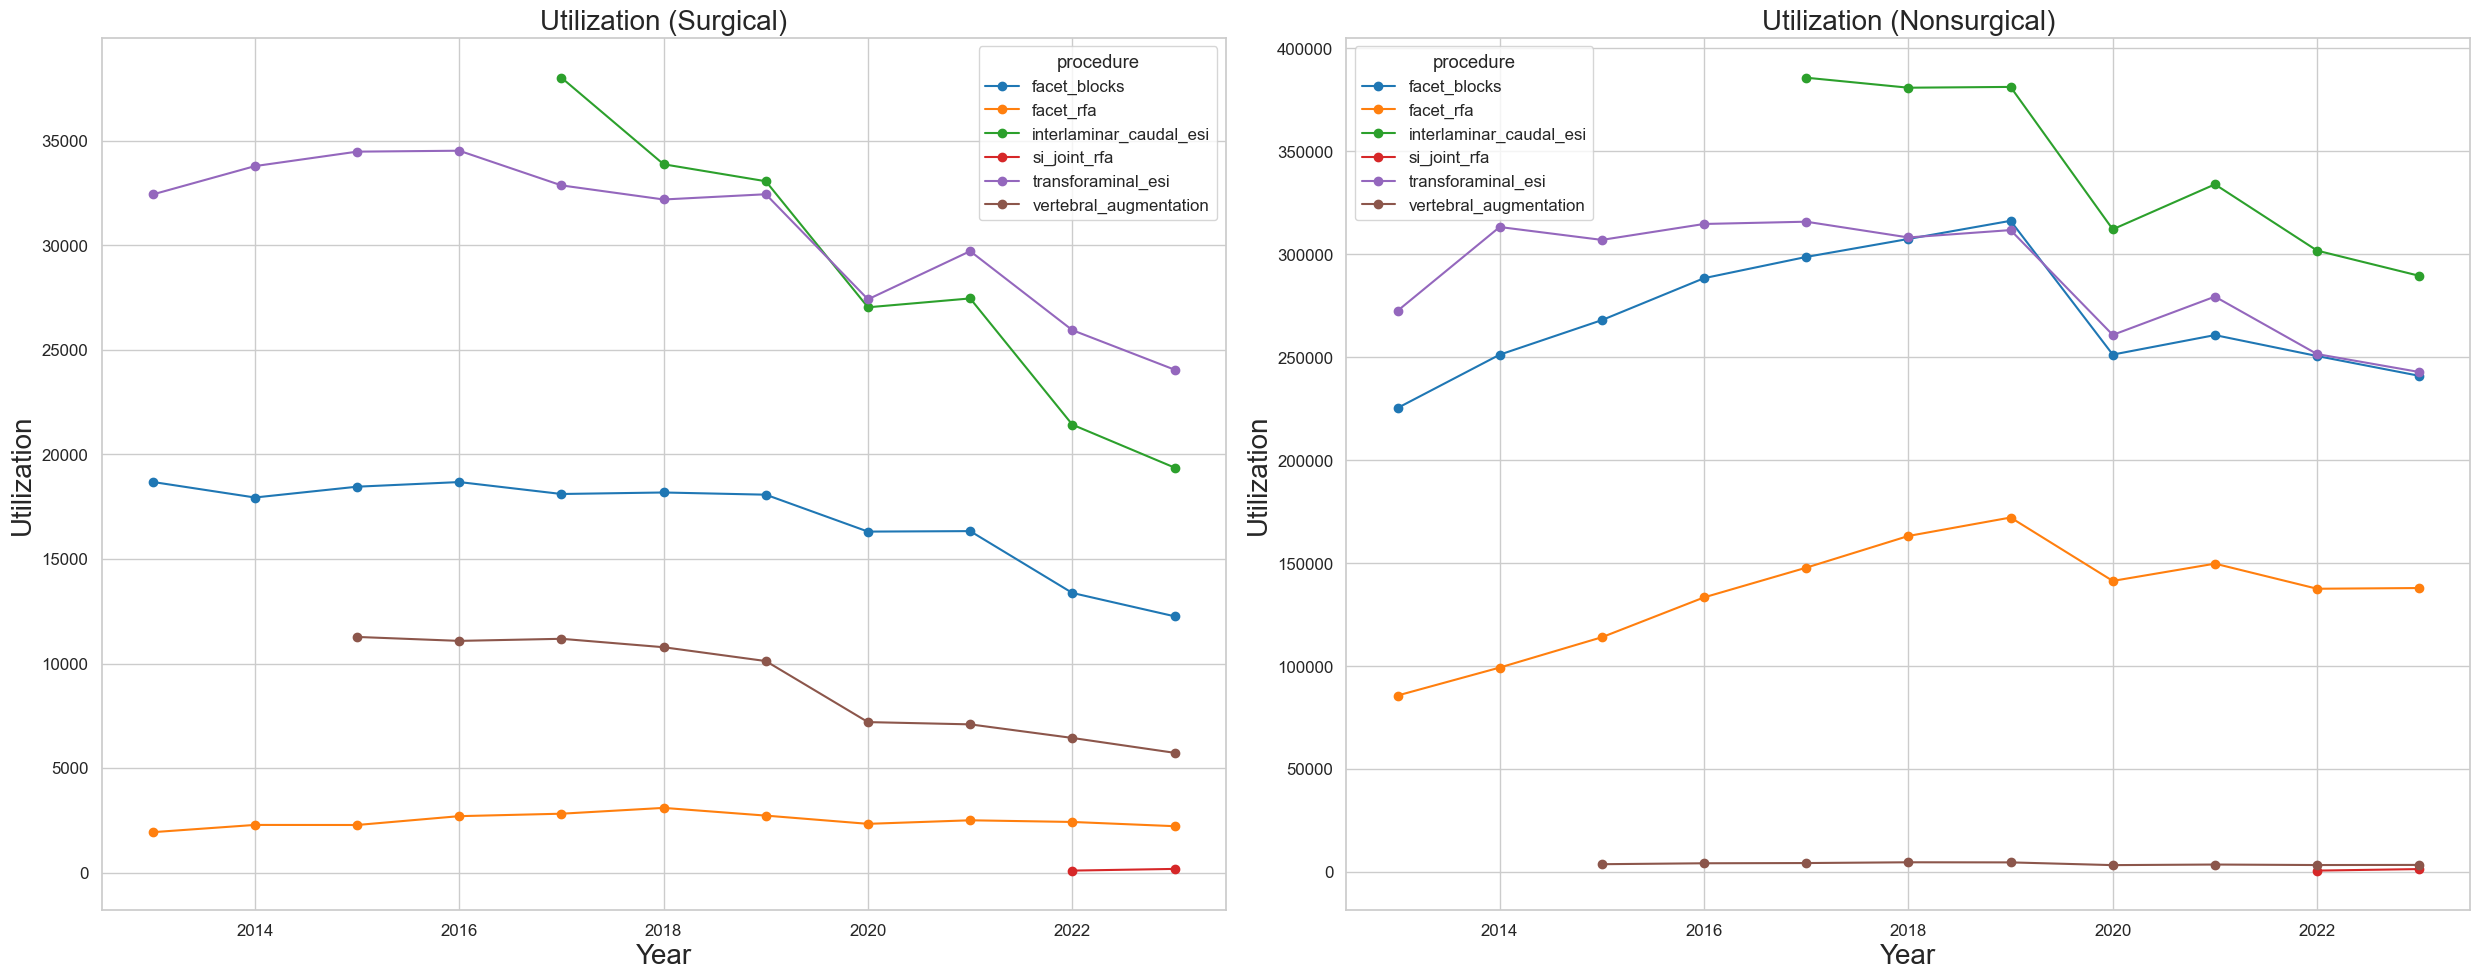

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')

        x = df_sorted['year']
        y = df_sorted['Sum_Utilization']

        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Utilization", fontsize=20)
    axs[i].set_title(f"Utilization ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [29]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 
# for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
#     grouped = specialty.groupby(groupby_key)
#     p_num = 0
    
#     for label, df in grouped:
#         if label in ('vertebral_augmentation', 'decompression_np', 'percutaneous_laminotomy_laminectomy'):
#             # Sort by year to ensure proper line plotting
#             df_sorted = df.sort_values('year')
    
#             x = df_sorted['year']
#             y = df_sorted['Sum_Utilization']
    
#             axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
#         p_num += 1
    
#     axs[i].legend(title=groupby_key)
#     axs[i].set_xlabel("Year", fontsize=20)
#     axs[i].set_ylabel("Utilization", fontsize=20)
#     axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

# plt.tight_layout()

In [115]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
# for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
#     grouped = specialty.groupby(groupby_key)
#     p_num = 0
    
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')

#         x = df_sorted['year']
#         y = df_sorted['Sum_Utilization']

#         axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
#         p_num += 1
    
#     axs[i].legend(title=groupby_key)
#     axs[i].set_xlabel("Year")
#     axs[i].set_ylabel("log(Utilization)")
#     axs[i].set_title(f"Utilization ({specialty_name[i]})")
#     axs[i].set_yscale("log")

# plt.tight_layout()

## Average Standardized Payment

In [46]:
# Bootstrap CIs for utilization-weighted aggregate price
ci_surg = bootstrap_agg_price_ci(surg_data, groupby_key)
util_2023_2013_adj_surg = util_2023_2013_adj_surg.merge(ci_surg, on=[groupby_key, 'year'], how='left')

ci_nonsurg = bootstrap_agg_price_ci(nonsurg_data, groupby_key)
util_2023_2013_adj_nonsurg = util_2023_2013_adj_nonsurg.merge(ci_nonsurg, on=[groupby_key, 'year'], how='left')

In [49]:
util_2023_2013_adj_nonsurg.keys()

Index(['procedure', 'year', 'Sum_Utilization', 'Sum_Spend', 'Sum_Pymt',
       'Sum_Spend_adj', 'Sum_Pymt_adj', 'Mean_provider_price_per_service_adj',
       'Mean_provider_price_per_service_adj_sem', 'Mean_provider_pymt_adj',
       'Mean_provider_pymt_adj_sem', 'Sum_Provider', 'Avg_Price_per_service',
       'Avg_Price_per_service_adj', 'Avg_Pymt_per_service',
       'Avg_Pymt_per_service_adj', 'CI_lower_agg_price_adj',
       'CI_upper_agg_price_adj'],
      dtype='object')

In [50]:
util_2023_2013_adj_surg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_surg['CI_lower_agg_price_adj']
util_2023_2013_adj_surg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_surg['CI_upper_agg_price_adj']

util_2023_2013_adj_nonsurg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_nonsurg['CI_lower_agg_price_adj']
util_2023_2013_adj_nonsurg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_nonsurg['CI_upper_agg_price_adj']

In [17]:
# util_2023_2013_adj_surg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_surg['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_surg['Avg_Price_per_service_adj_sem']
# util_2023_2013_adj_surg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_surg['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_surg['Avg_Price_per_service_adj_sem']

# util_2023_2013_adj_nonsurg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']
# util_2023_2013_adj_nonsurg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']

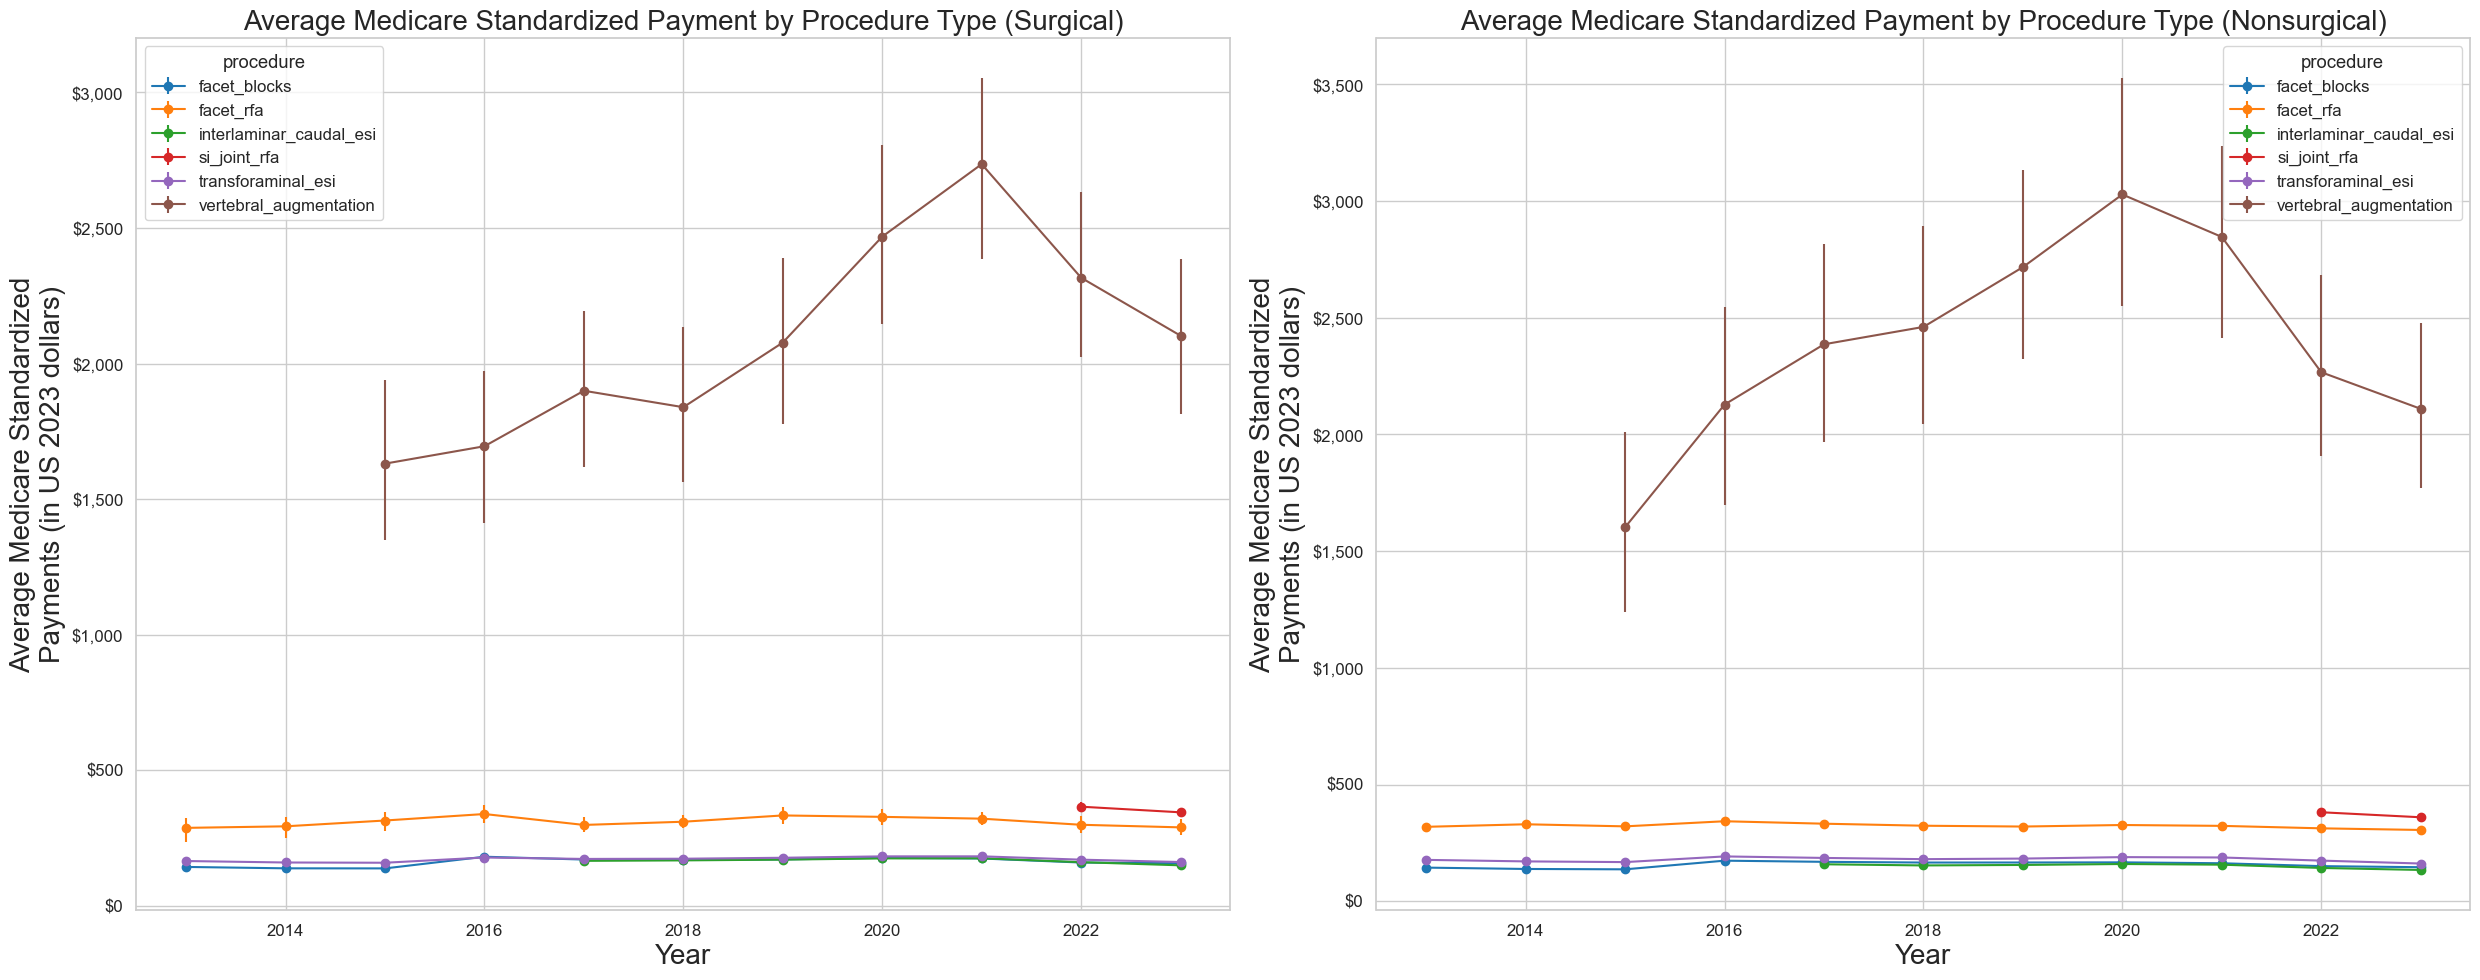

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Avg_Price_per_service_adj']
    
        # Compute error bars from CI bounds
        yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
        axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Average Medicare Standardized Payment by Procedure Type ({specialty_name[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

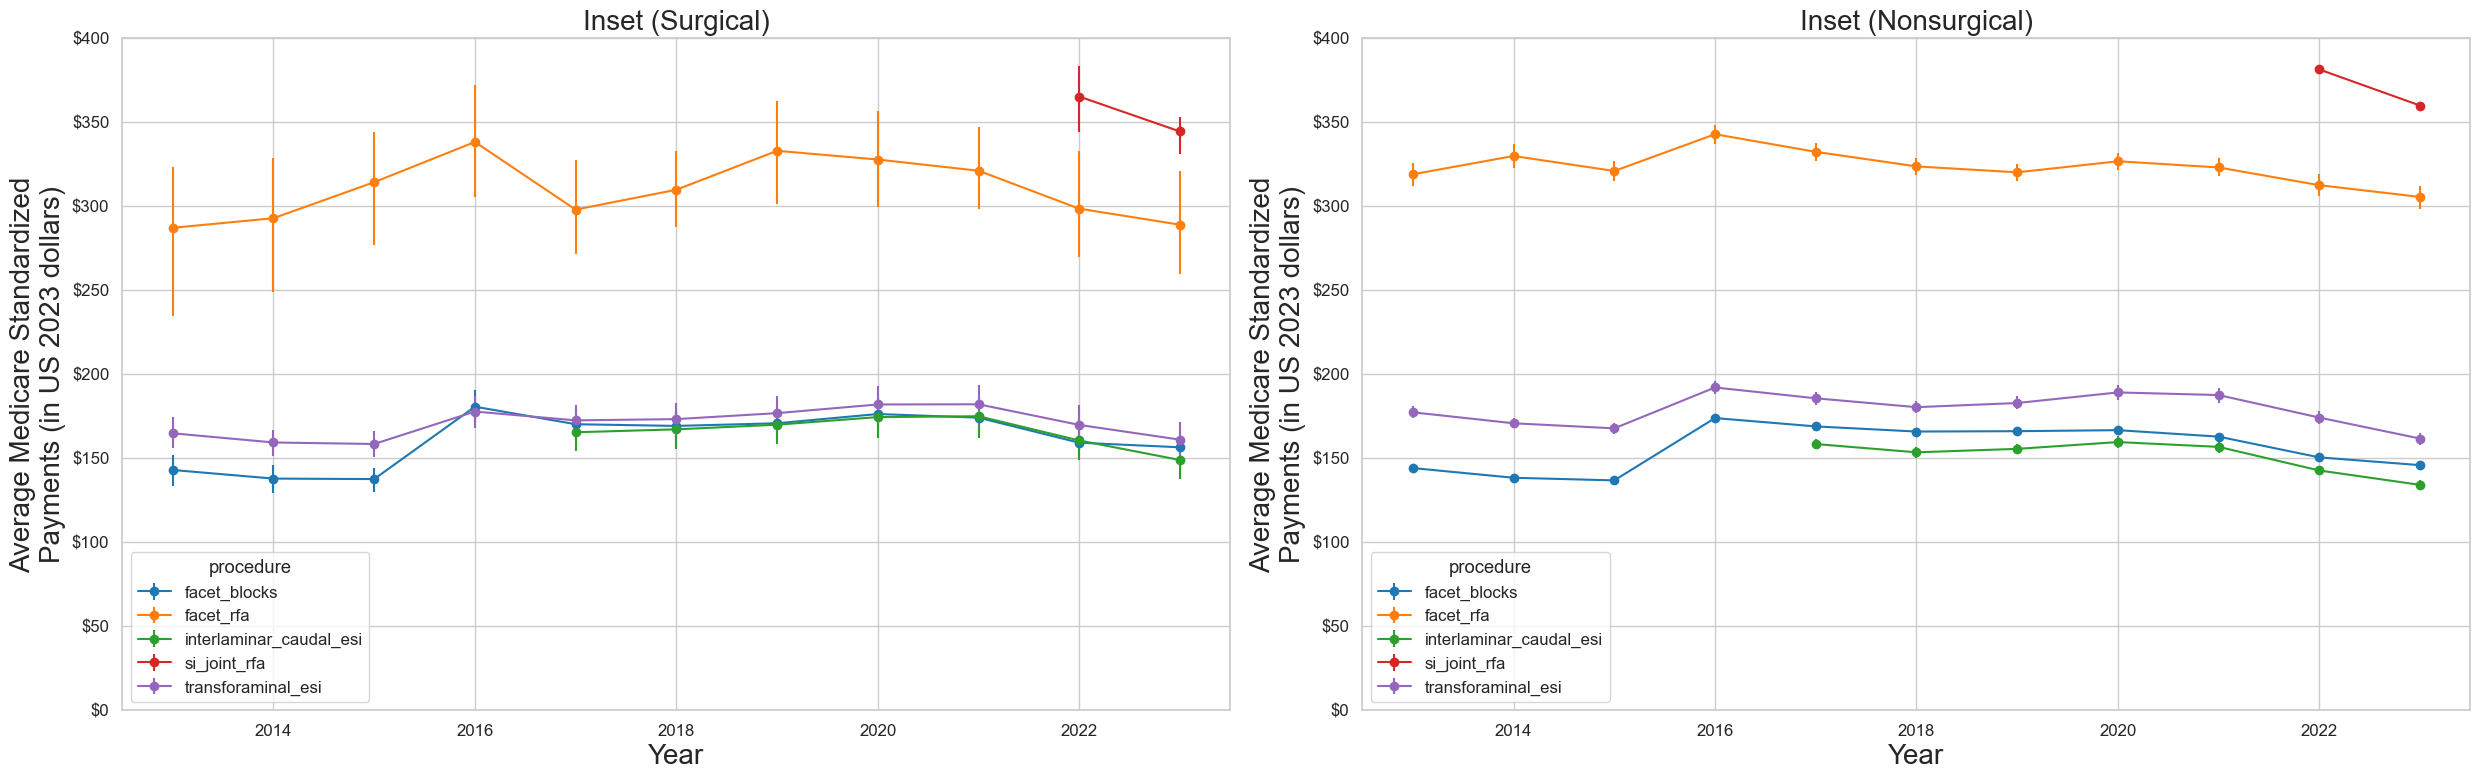

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 
for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('facet_rfa', 'transforaminal_esi', 'facet_blocks', 'interlaminar_caudal_esi', 'si_joint_rfa'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Avg_Price_per_service_adj']
        
            # Compute error bars from CI bounds
            yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
            axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

    axs[i].set_ylim([0, 400])

plt.tight_layout()

## Average Standardized Payment Growth Rate

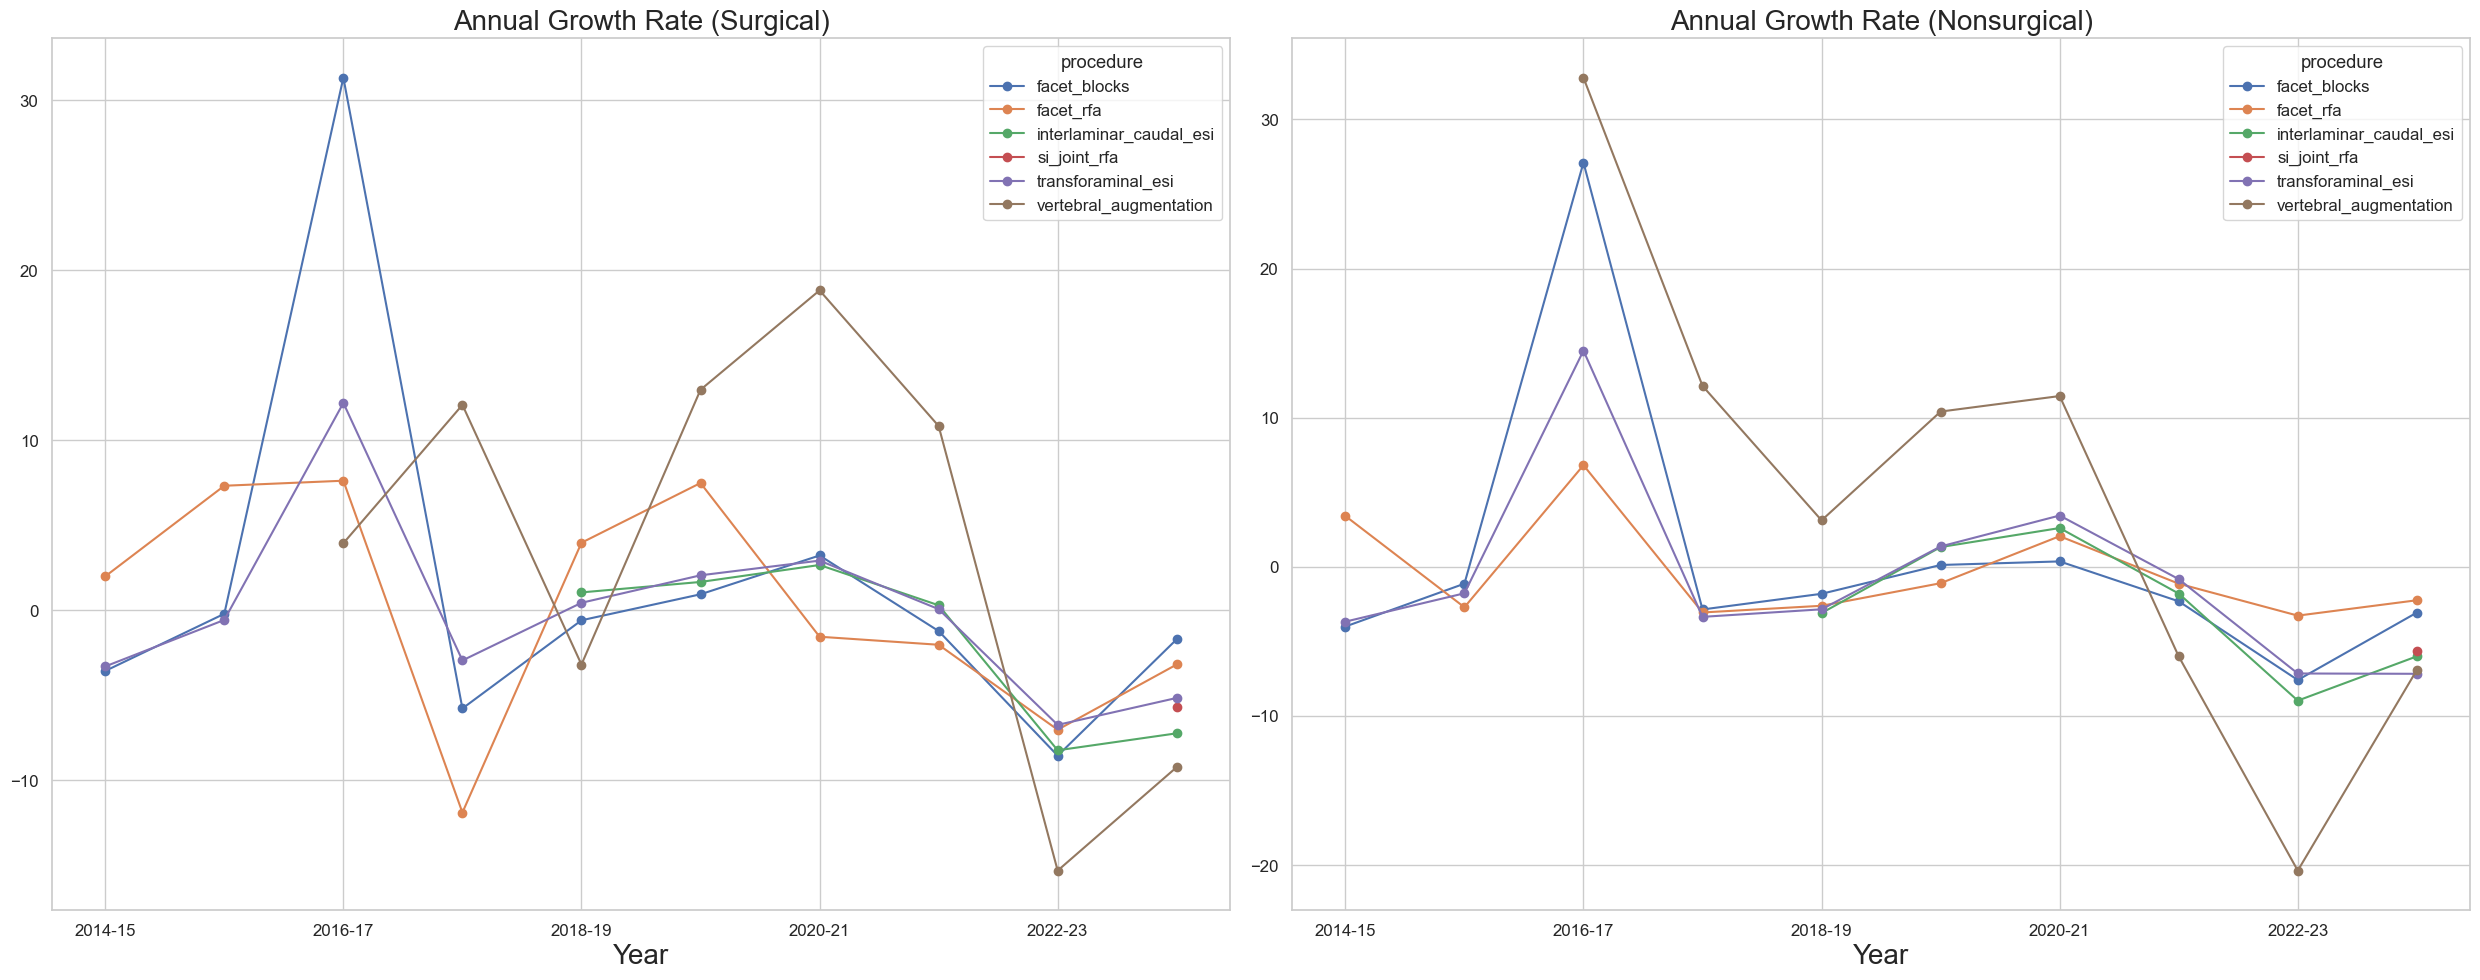

In [64]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    # axs[i].set_ylim([-25, 100])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [65]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_aagr_by_procedure.csv", index=False)

In [60]:
# aagr = {'Surgical': [], 'Nonsurgical': []}
# aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
# all_deltas = {'Surgical': [], 'Nonsurgical': []}

# for i, specialty in enumerate([util_2023_2013_adj_surg_by_cpt, util_2023_2013_adj_nonsurg_by_cpt]):
#     grouped = specialty.groupby('HCPCS_Cd')
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')
        
#         x = df_sorted['year'].tolist()
#         y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
#         pairs = {x[i]: item for i, item in enumerate(y)}
    
#         x_new = list(range(2013, 2024))
    
#         y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
#         delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

#         axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

#         # Use this to compute AAGR per procedure later
#         aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

#         # Compute a version of AAGR without interpolation
#         delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
#         aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

#         # Use this to plot average growth rate across procedures later
#         all_deltas[specialty_name[i]].append(delta)

In [61]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['cpt', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_aagr_by_cpt_code.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_25017/2557951952.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


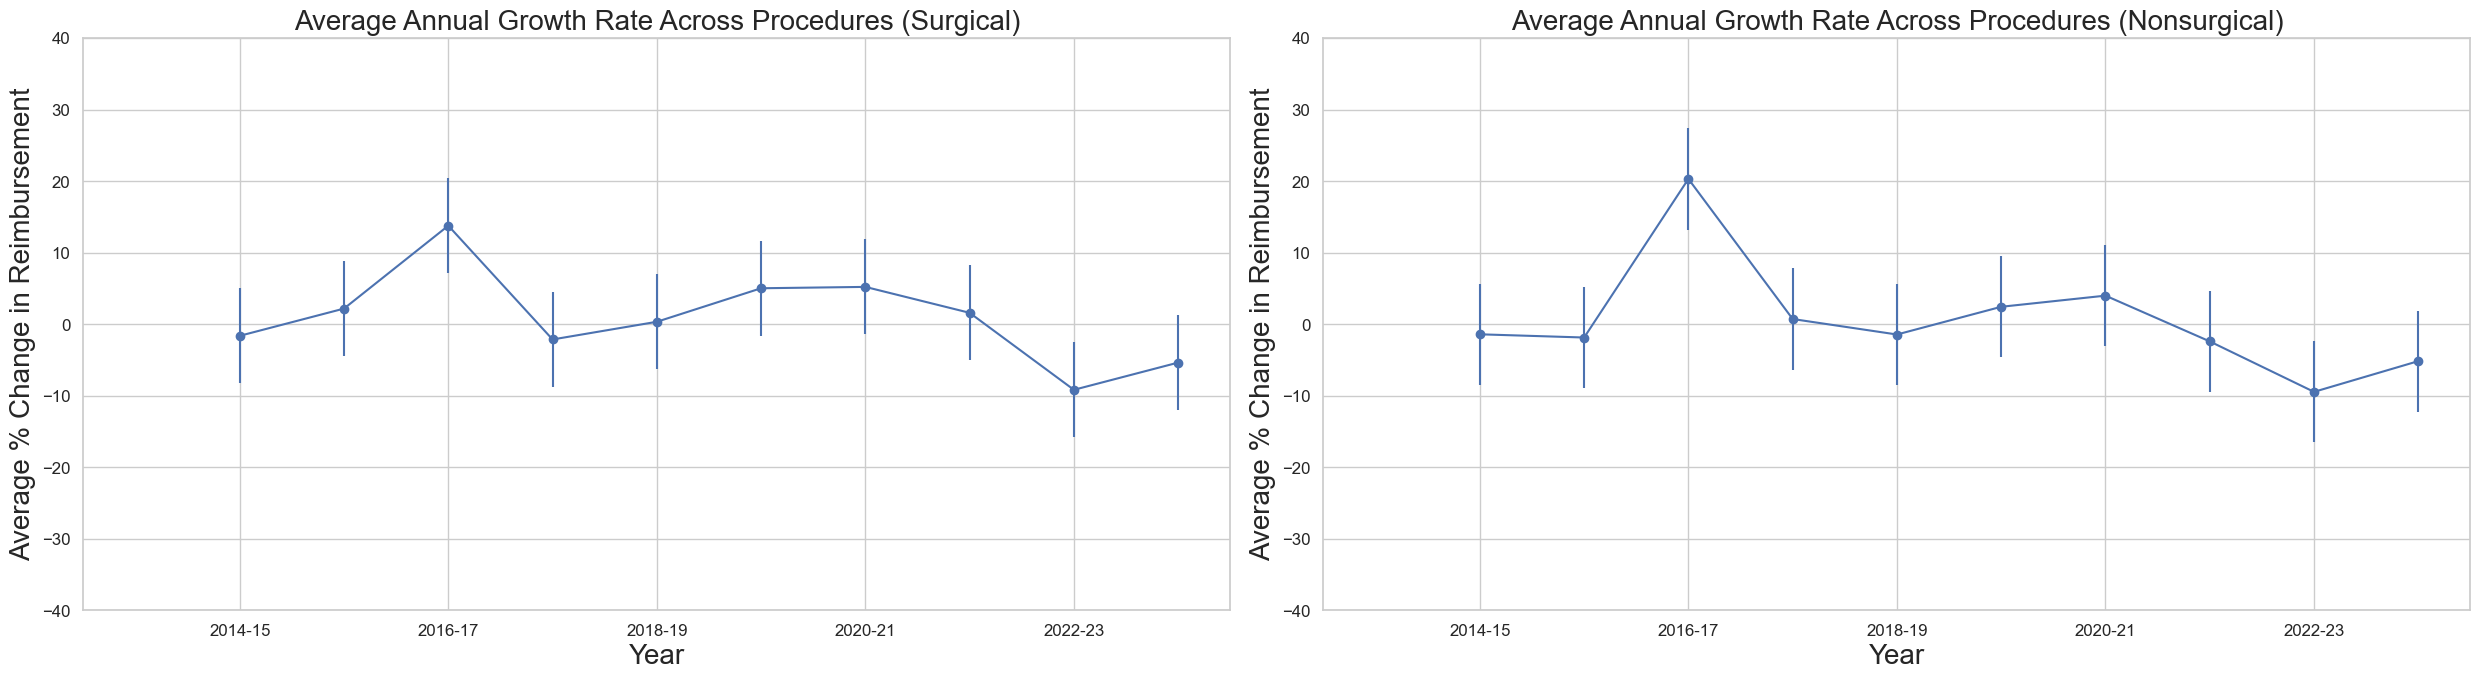

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement", fontsize=20)
    axs[i].set_ylim([-40, 40])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})", fontsize=20)

    i += 1

plt.tight_layout()

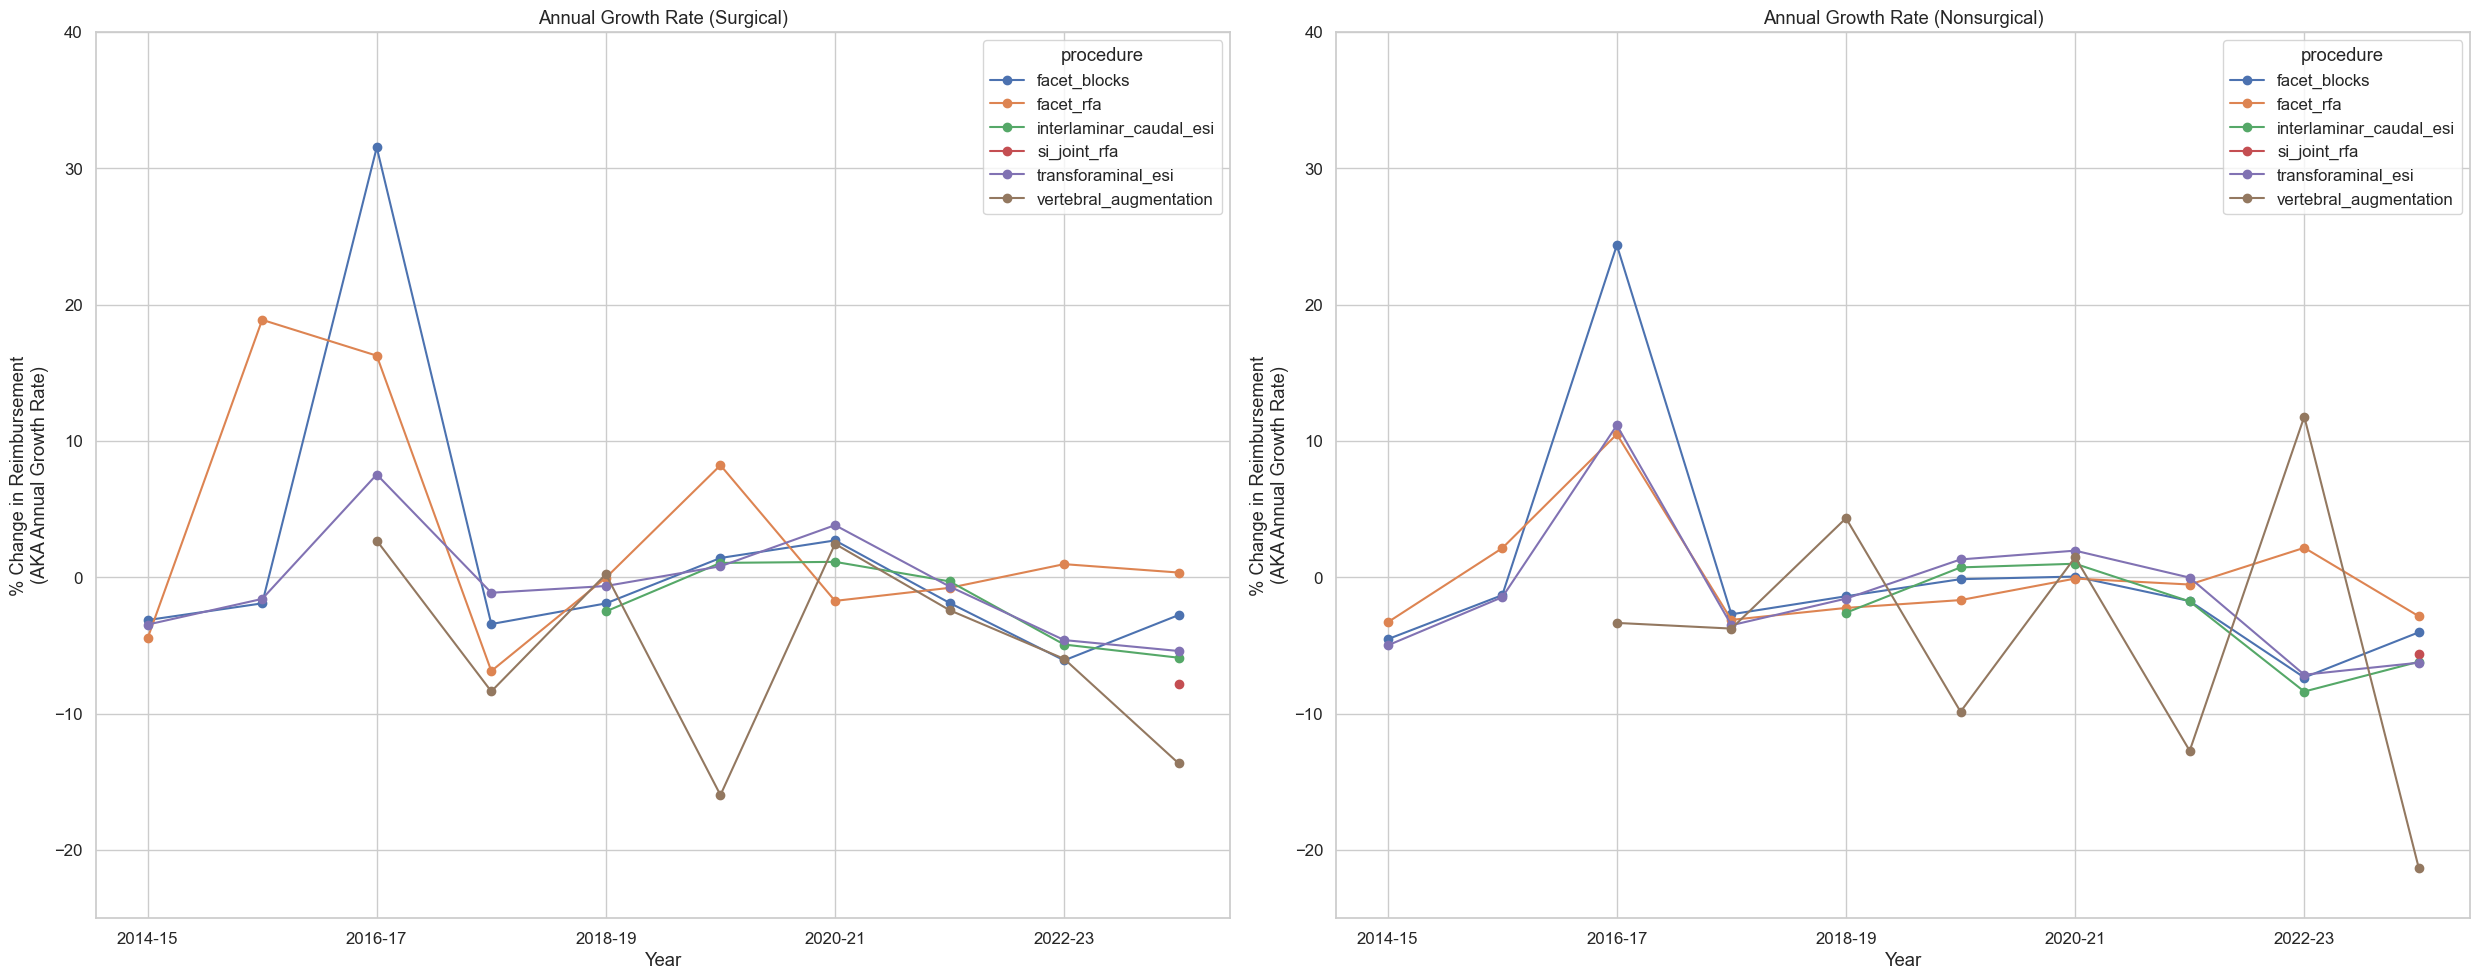

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        if label in ('decompression_np', 'percutaneous_laminotomy_laminectomy'):
            continue 

        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Reimbursement\n(AKA Annual Growth Rate)")
    axs[i].set_ylim([-25, 40])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_80404/798989267.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


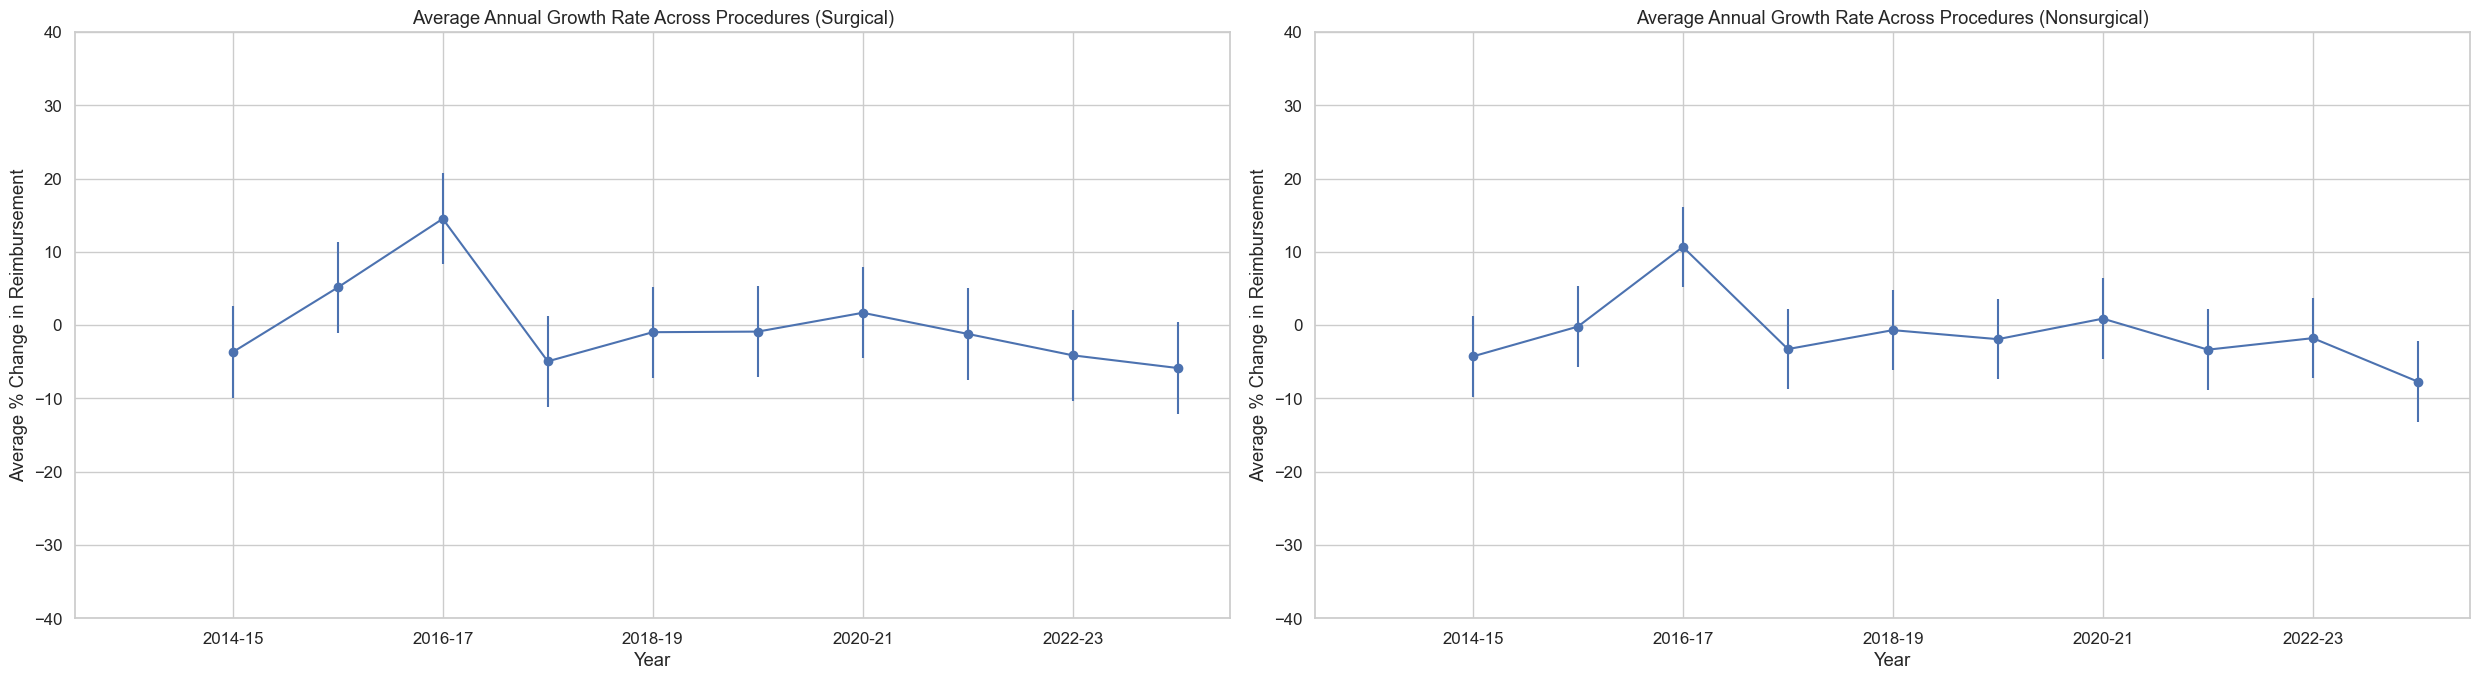

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement")
    axs[i].set_ylim([-40, 40])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()

## Total Payment

In [23]:
util_2023_2013_adj_surg['CI_lower_tot_pymt'] = util_2023_2013_adj_surg['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_surg['Tot_Pymt_adj_sem']
util_2023_2013_adj_surg['CI_upper_tot_pymt'] = util_2023_2013_adj_surg['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_surg['Tot_Pymt_adj_sem']

util_2023_2013_adj_nonsurg['CI_lower_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']
util_2023_2013_adj_nonsurg['CI_upper_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']

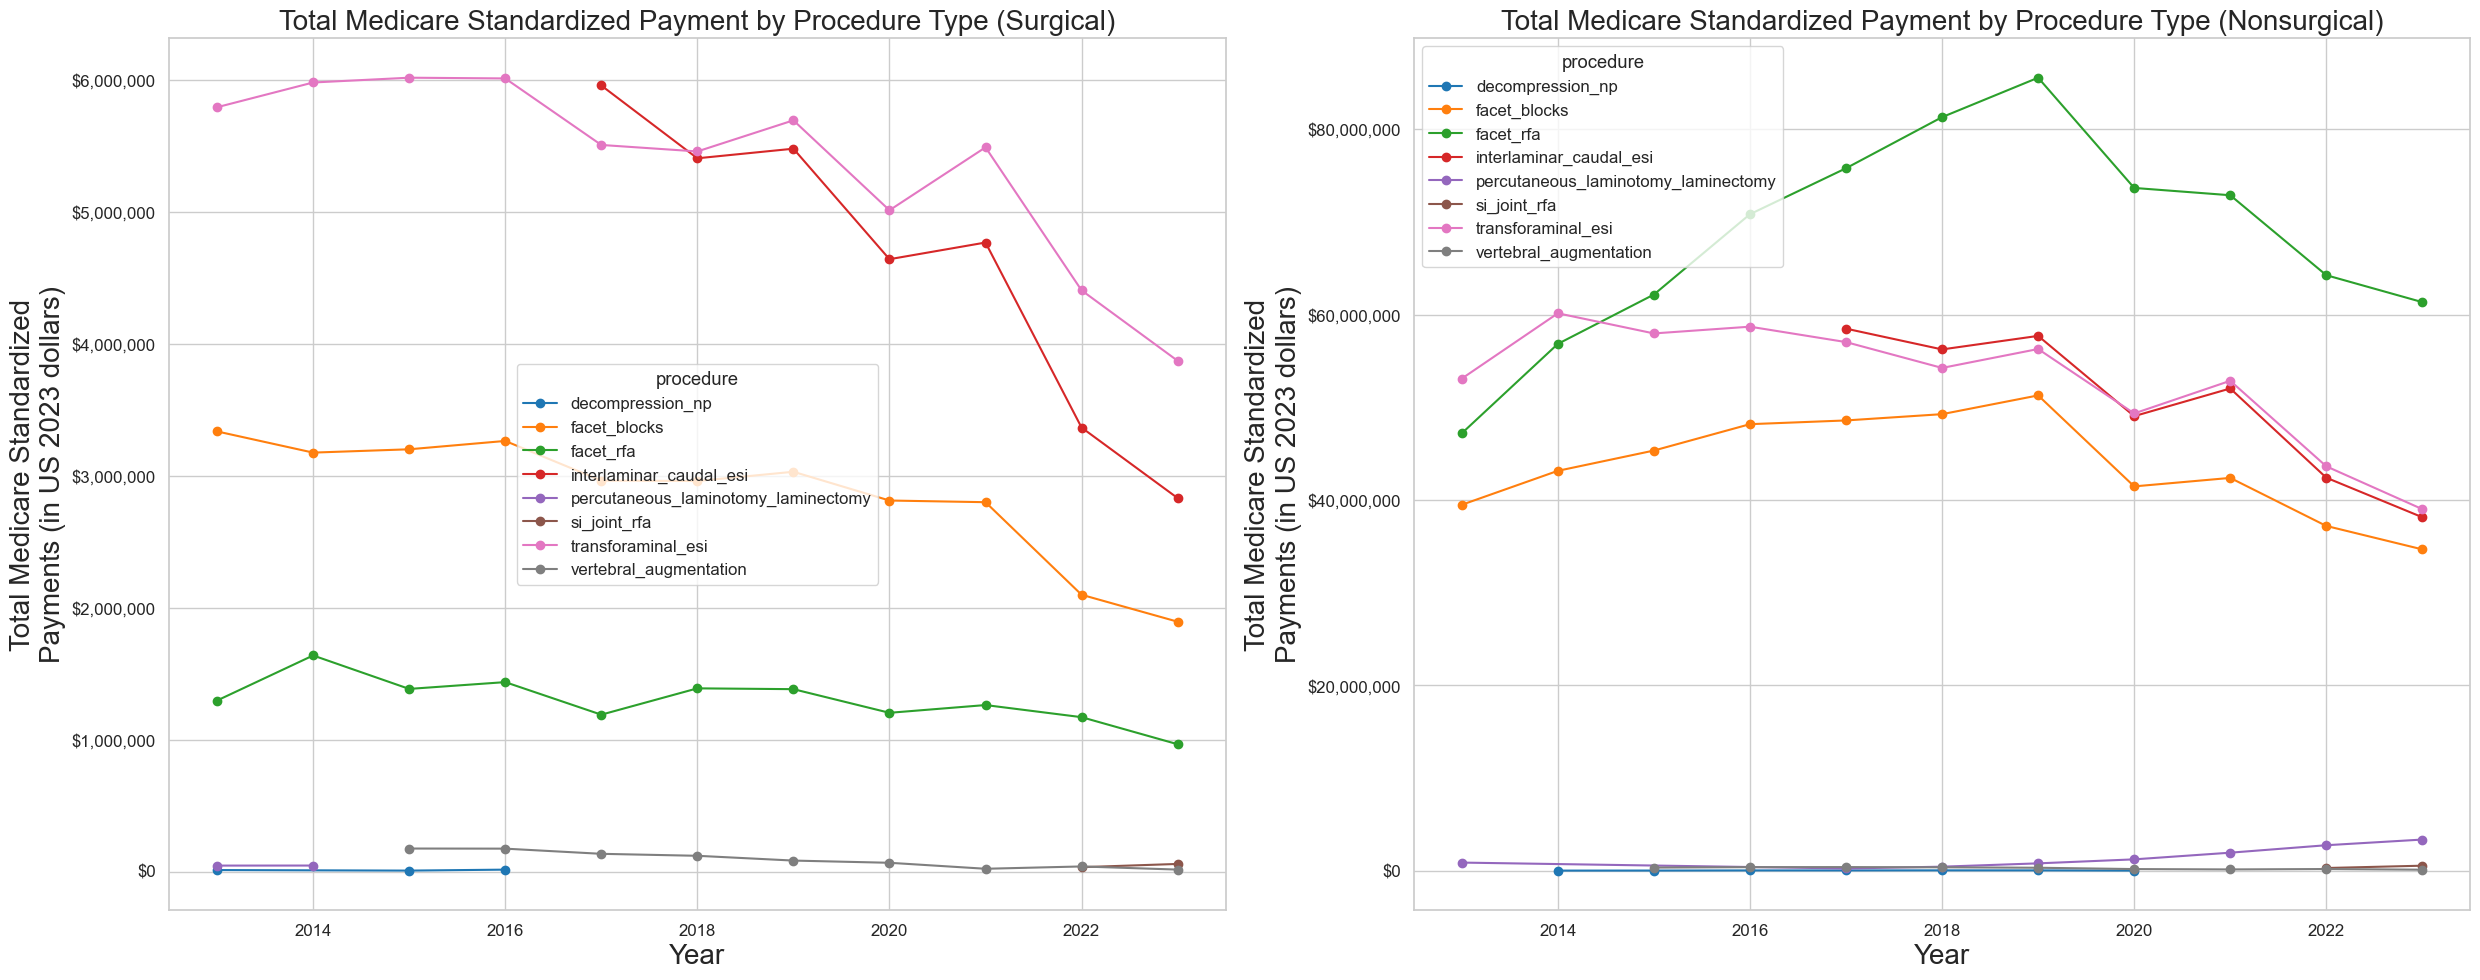

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0

    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Sum_Pymt_adj']
    
        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Total Medicare Standardized Payment by Procedure Type ({specialty_name[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

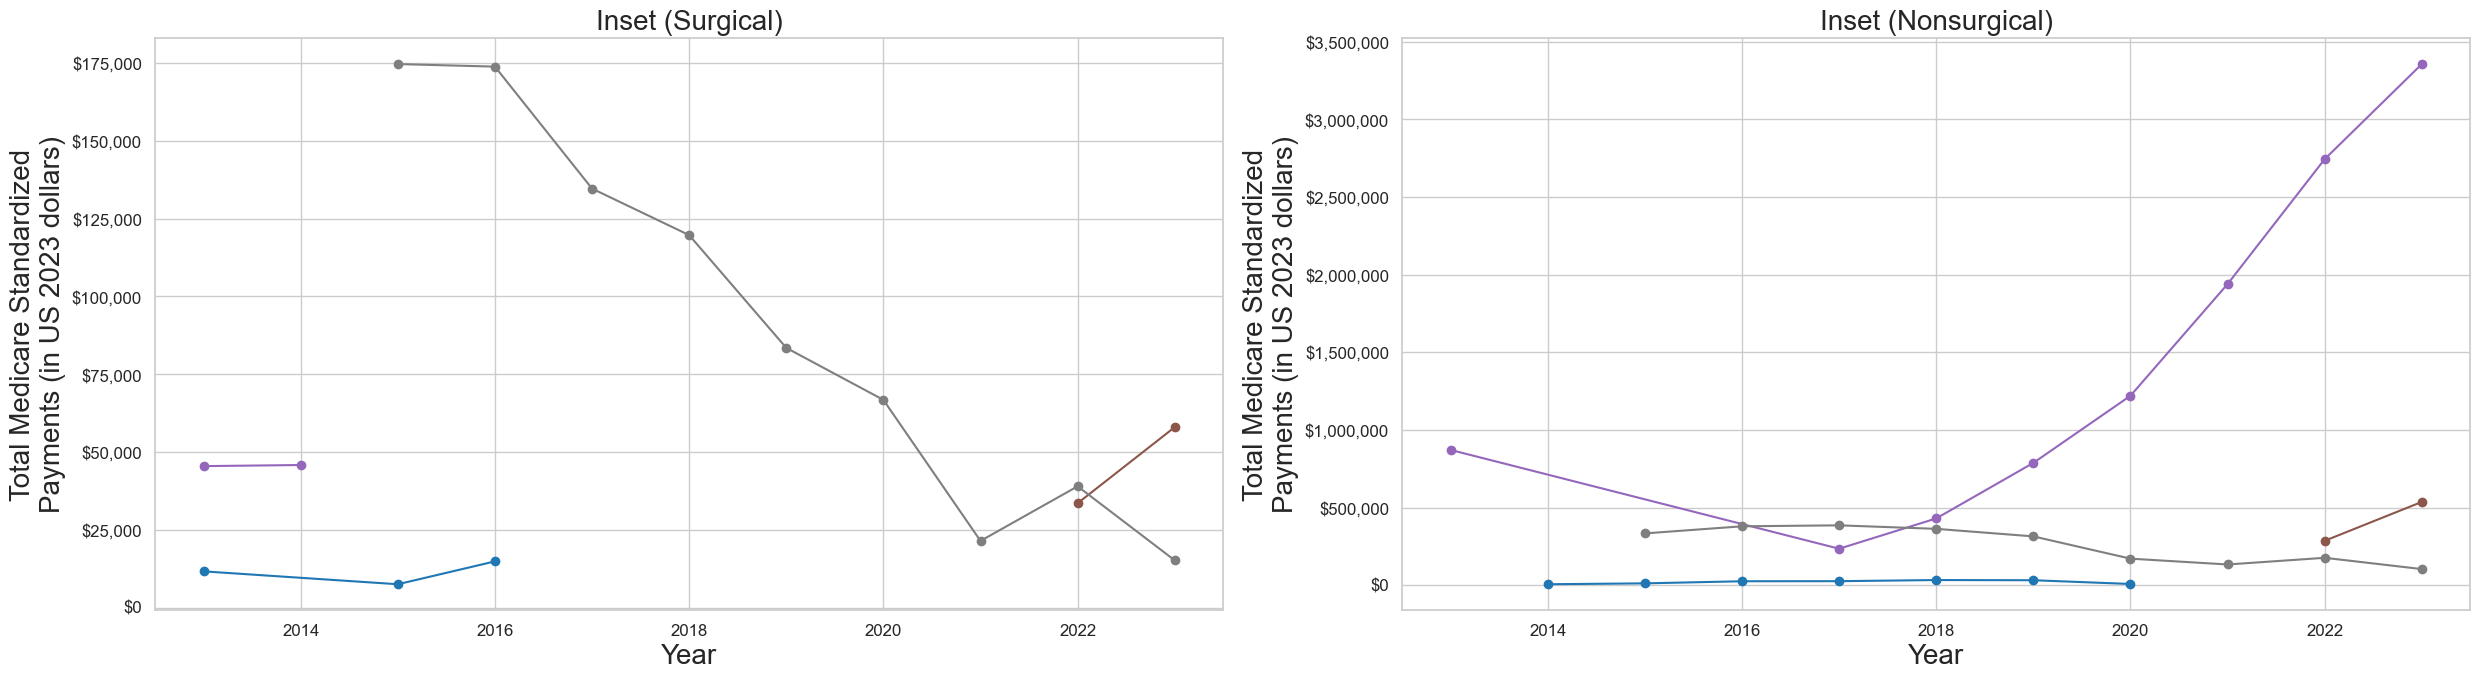

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('decompression_np', 'percutaneous_laminotomy_laminectomy', 'vertebral_augmentation', 'si_joint_rfa'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Sum_Pymt_adj']
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        
        p_num += 1
    
    # axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Total Payment Growth Rate

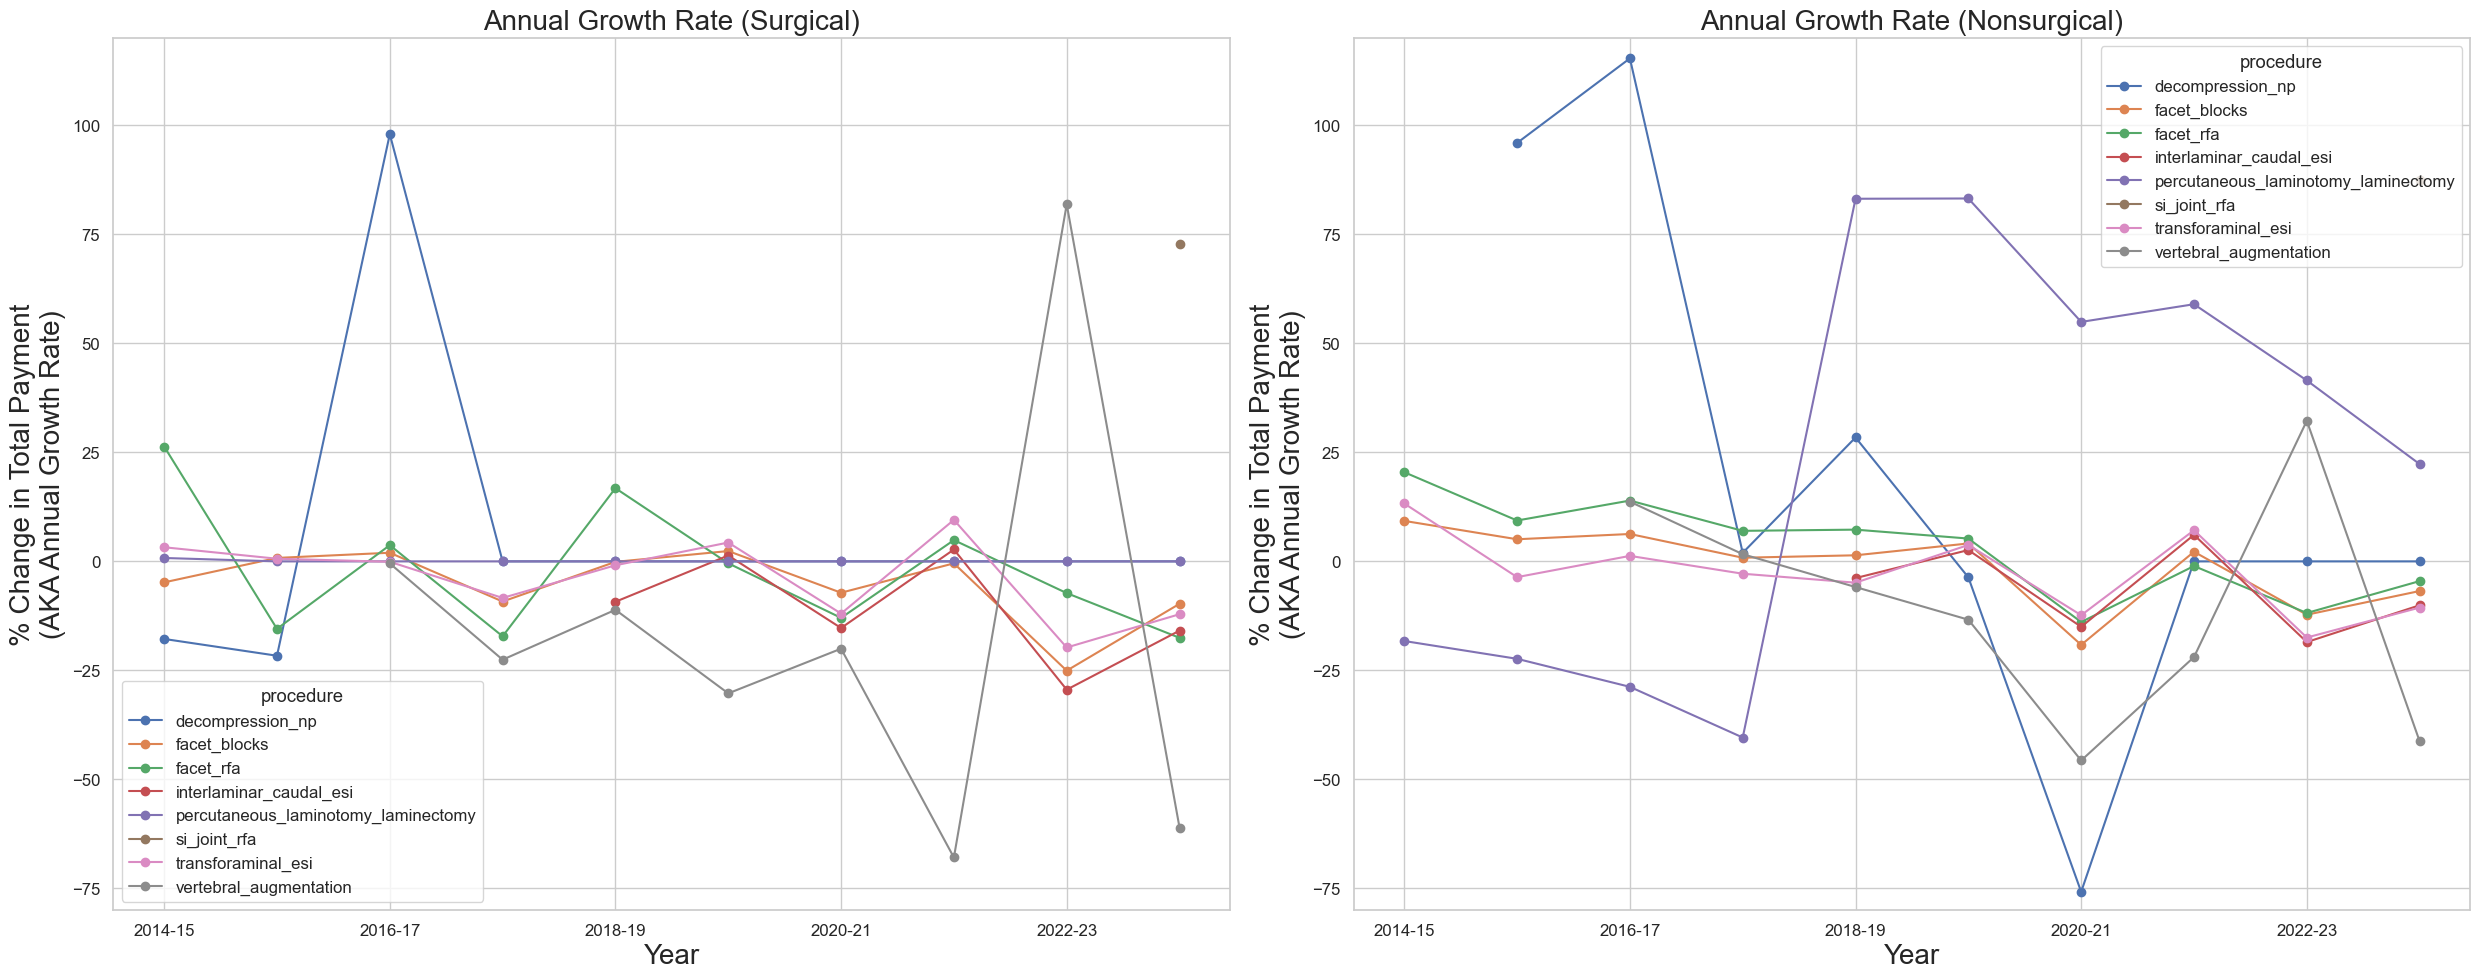

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)", fontsize=20)
    axs[i].set_ylim([-80, 120])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [38]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_total_pymt_aagr_by_procedure.csv", index=False)

In [39]:
aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg_by_cpt, util_2023_2013_adj_nonsurg_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

In [40]:
pd.DataFrame(
    aagr['Surgical'] + aagr['Nonsurgical'], columns=['cpt', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_total_pymt_aagr_by_cpt_code.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_65718/2043566546.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


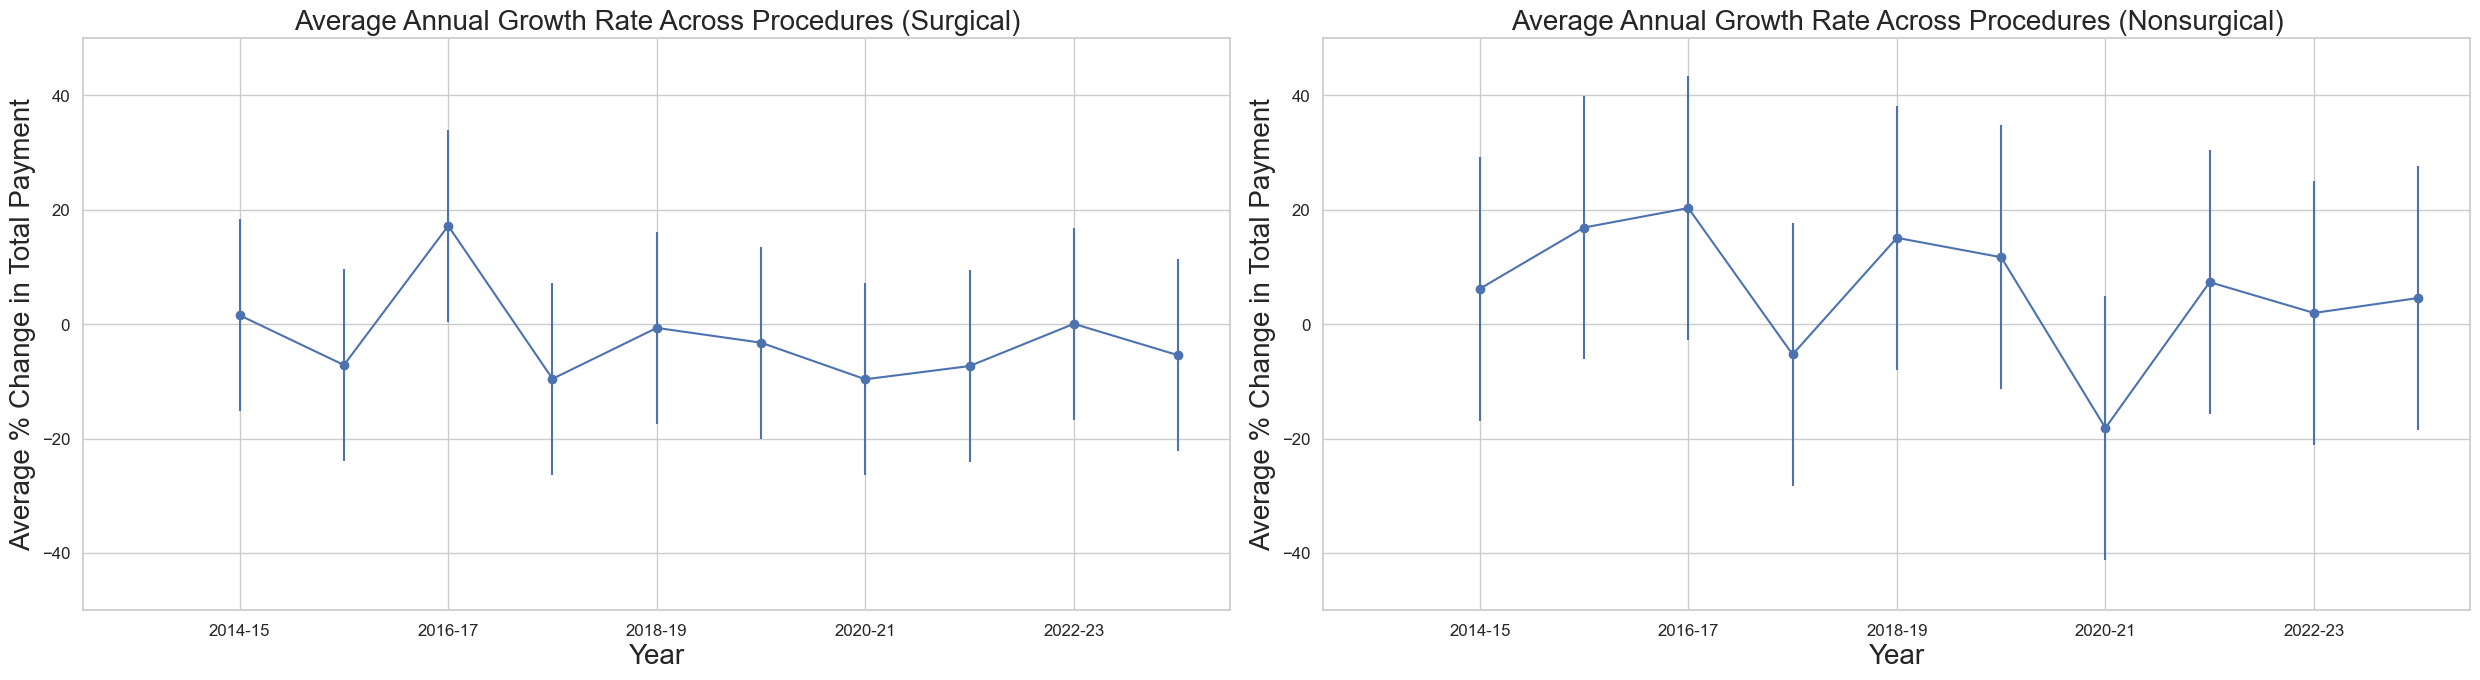

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment", fontsize=20)
    axs[i].set_ylim([-50, 50])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})", fontsize=20)

    i += 1

plt.tight_layout()

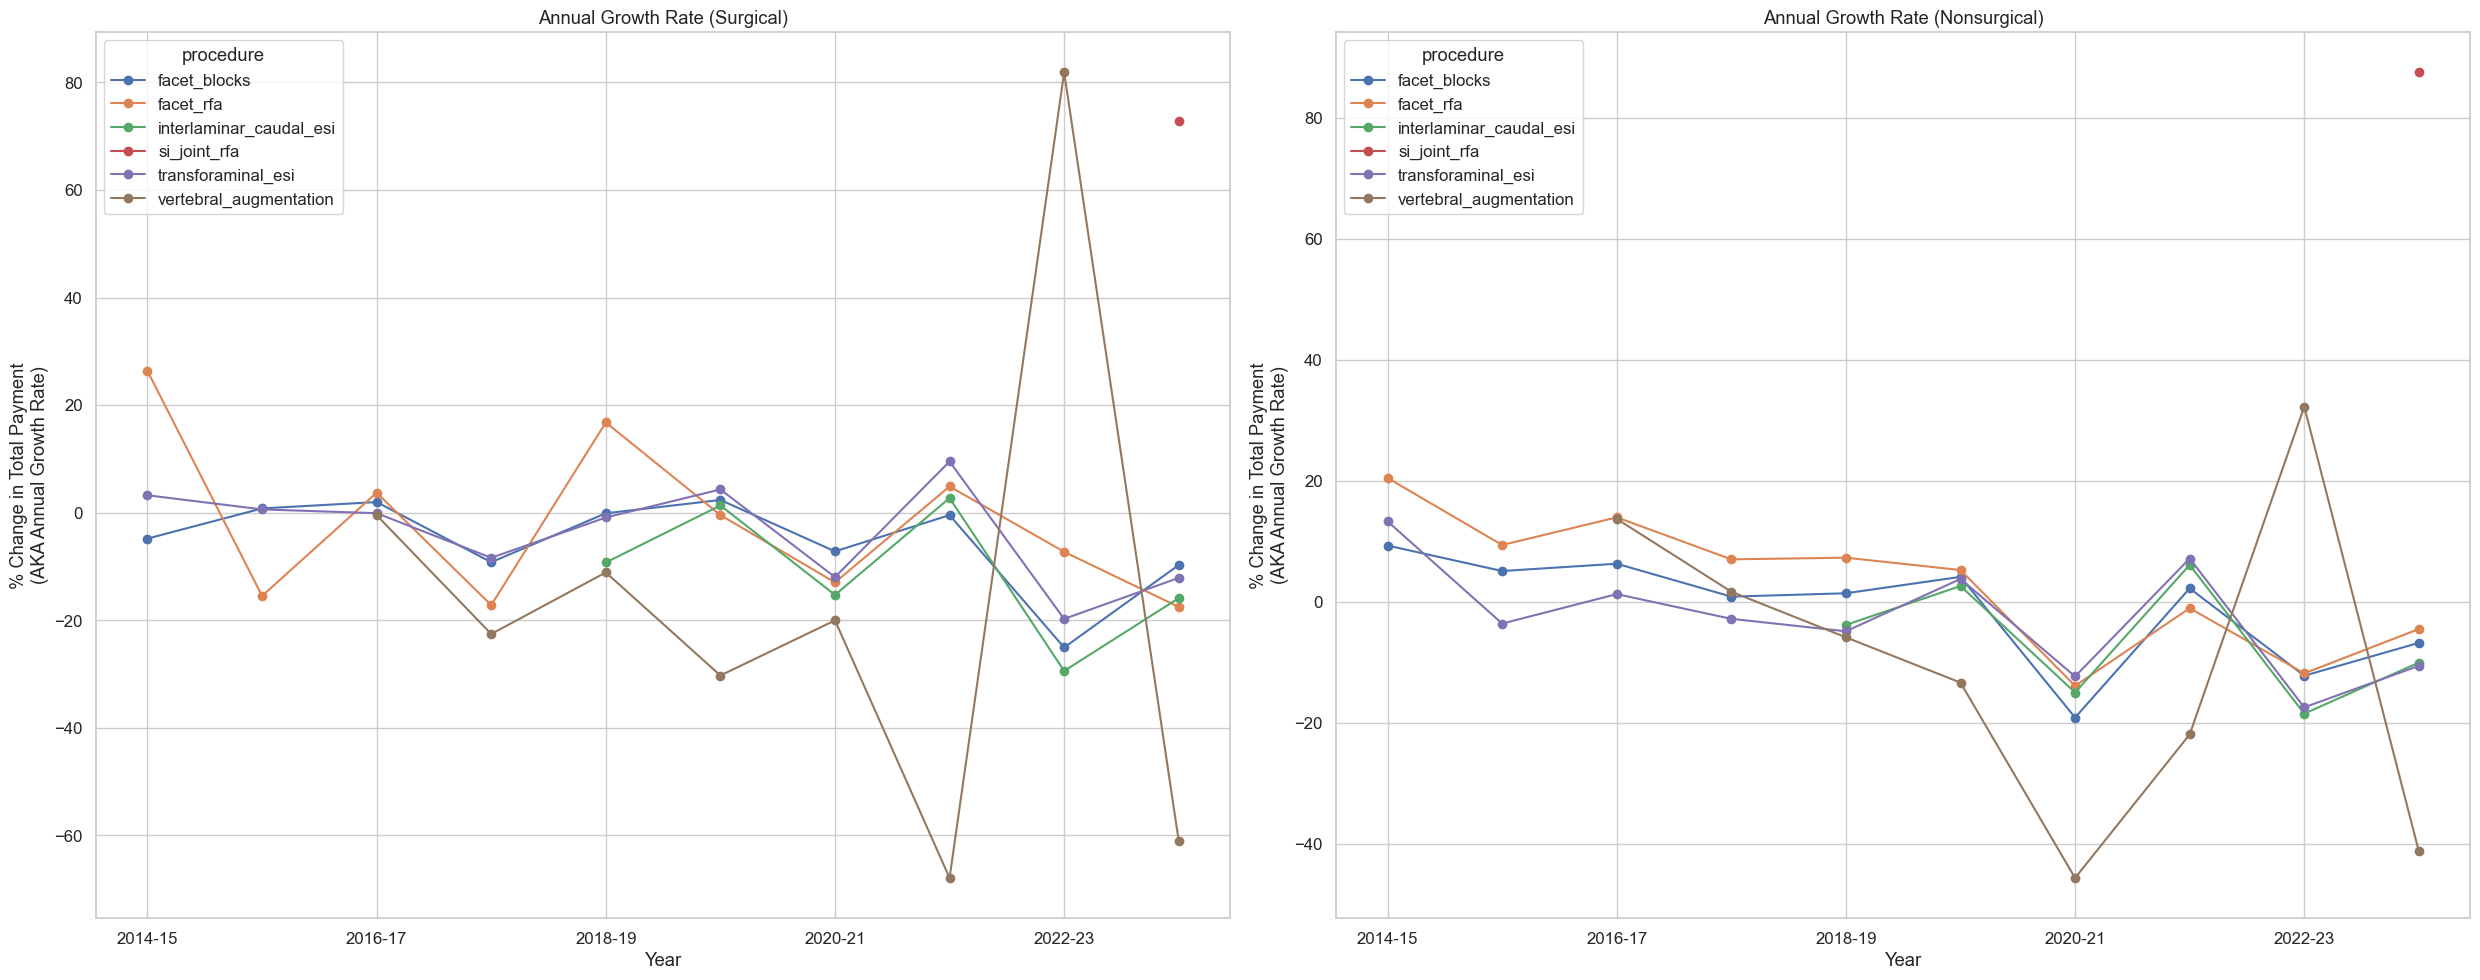

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Surgical': [], 'Nonsurgical': []}
aagr_no_interp = {'Surgical': [], 'Nonsurgical': []}
all_deltas = {'Surgical': [], 'Nonsurgical': []}

for i, specialty in enumerate([util_2023_2013_adj_surg, util_2023_2013_adj_nonsurg]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        if label in ('decompression_np', 'percutaneous_laminotomy_laminectomy'):
            continue
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp), specialty_name[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)")
    # axs[i].set_ylim([-75, 750])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})")

plt.tight_layout()

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_80404/1703230778.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


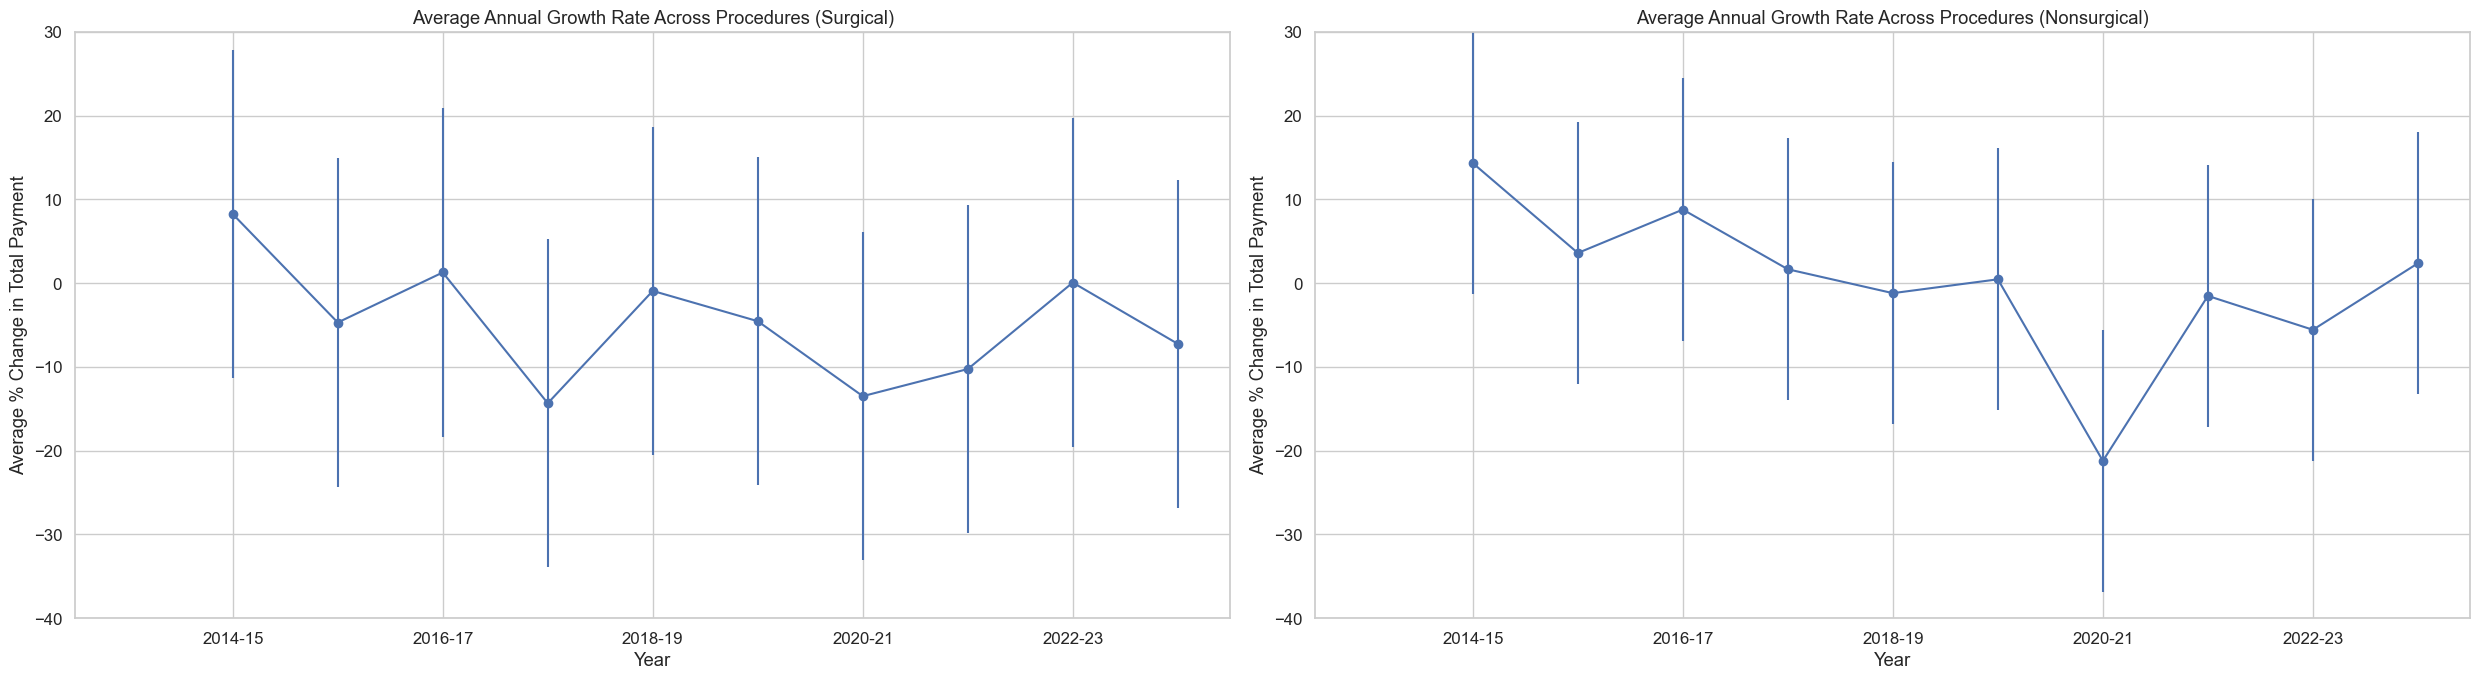

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment")
    axs[i].set_ylim([-40, 30])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})")

    i += 1

plt.tight_layout()

# Analysis: Pain vs. Spine

In [23]:
specialty_name_updated = ["Nonsurgeon Pain", "Neurosurgery Spine"]

In [24]:
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", 
    "tab:pink", "tab:gray", "tab:olive", "tab:cyan", "black", "gold" 
]

## Utilization

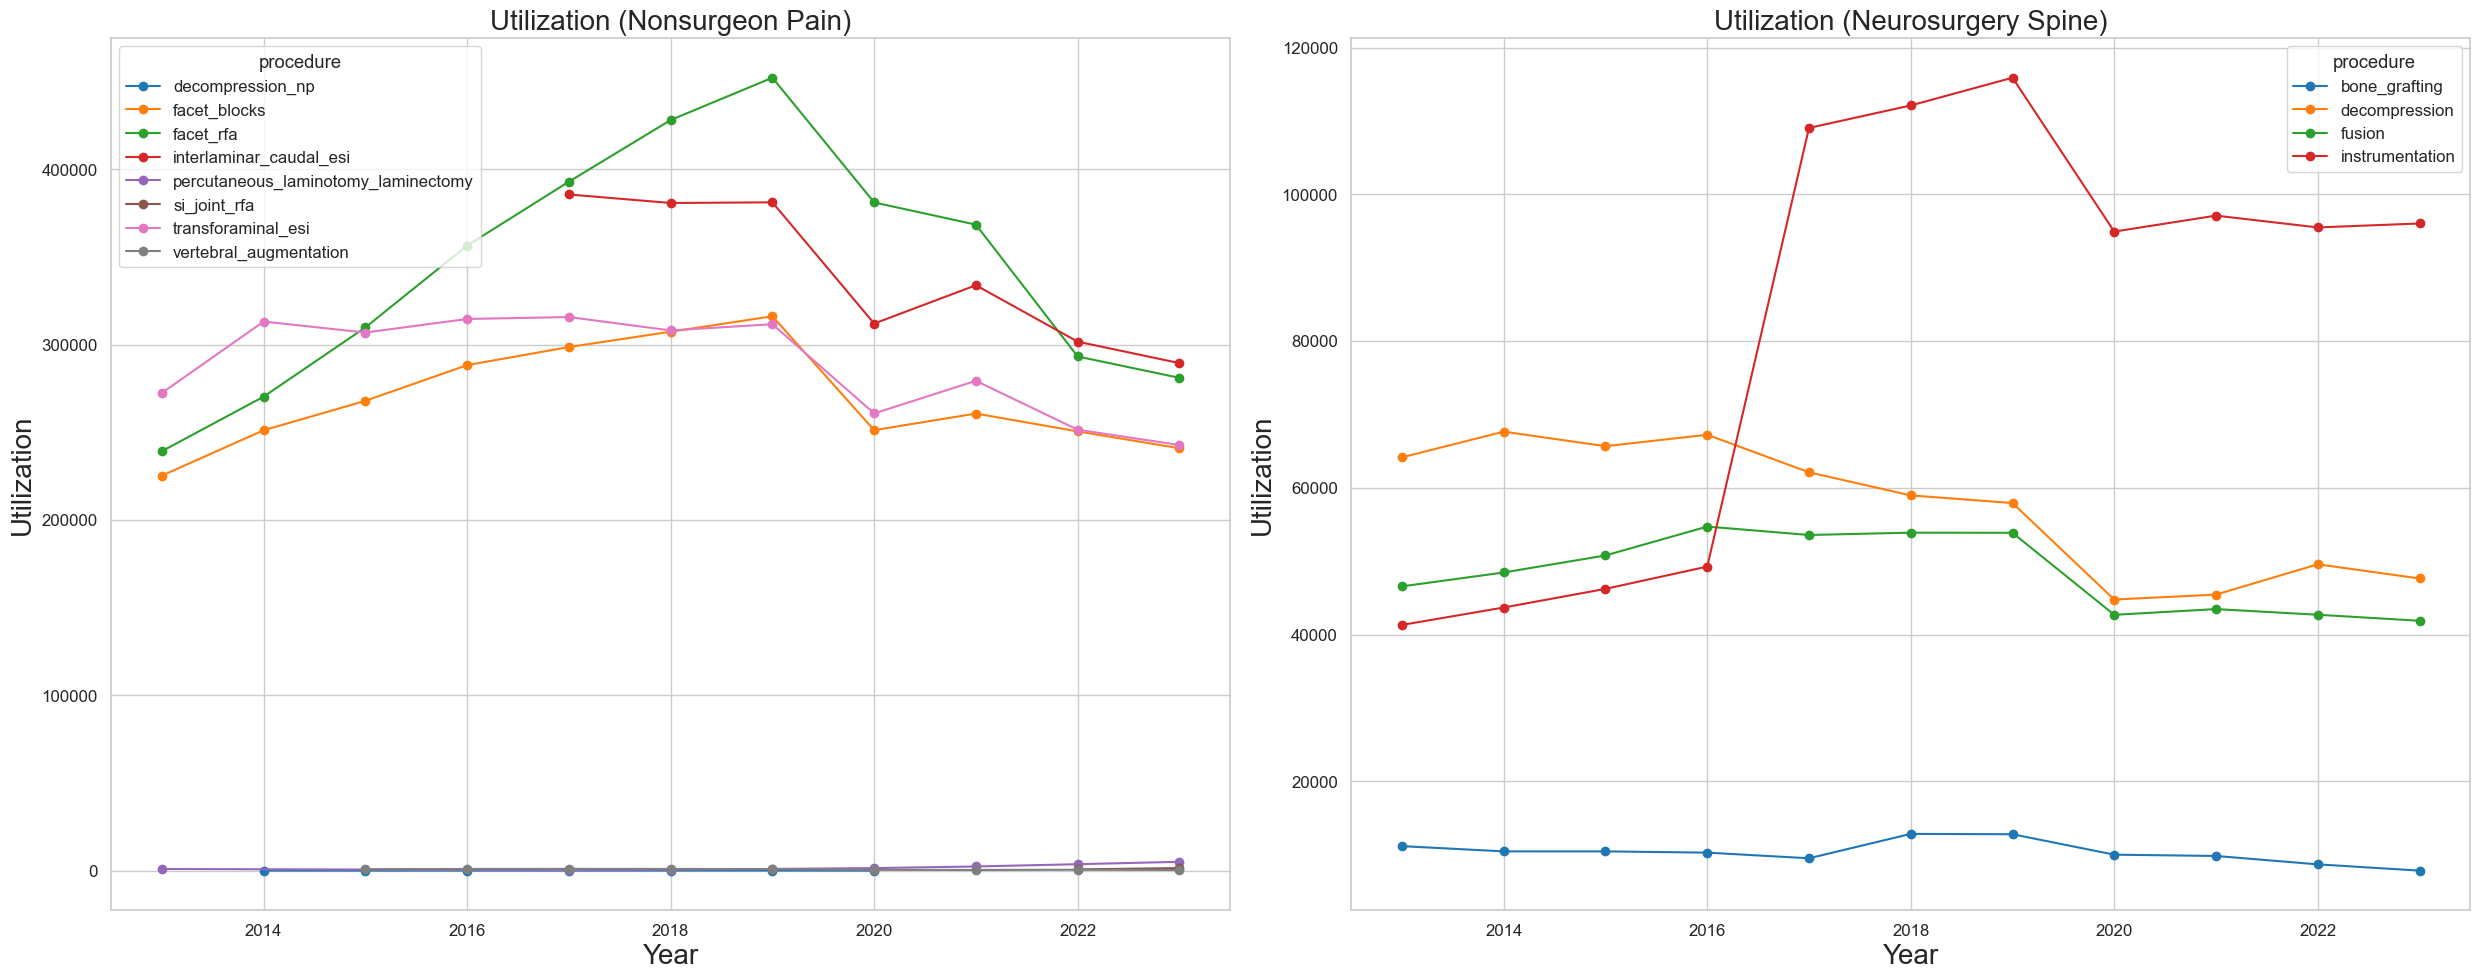

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')

        x = df_sorted['year']
        y = df_sorted['Sum_Utilization']

        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Utilization", fontsize=20)
    axs[i].set_title(f"Utilization ({specialty_name_updated[i]})", fontsize=20)

plt.tight_layout()

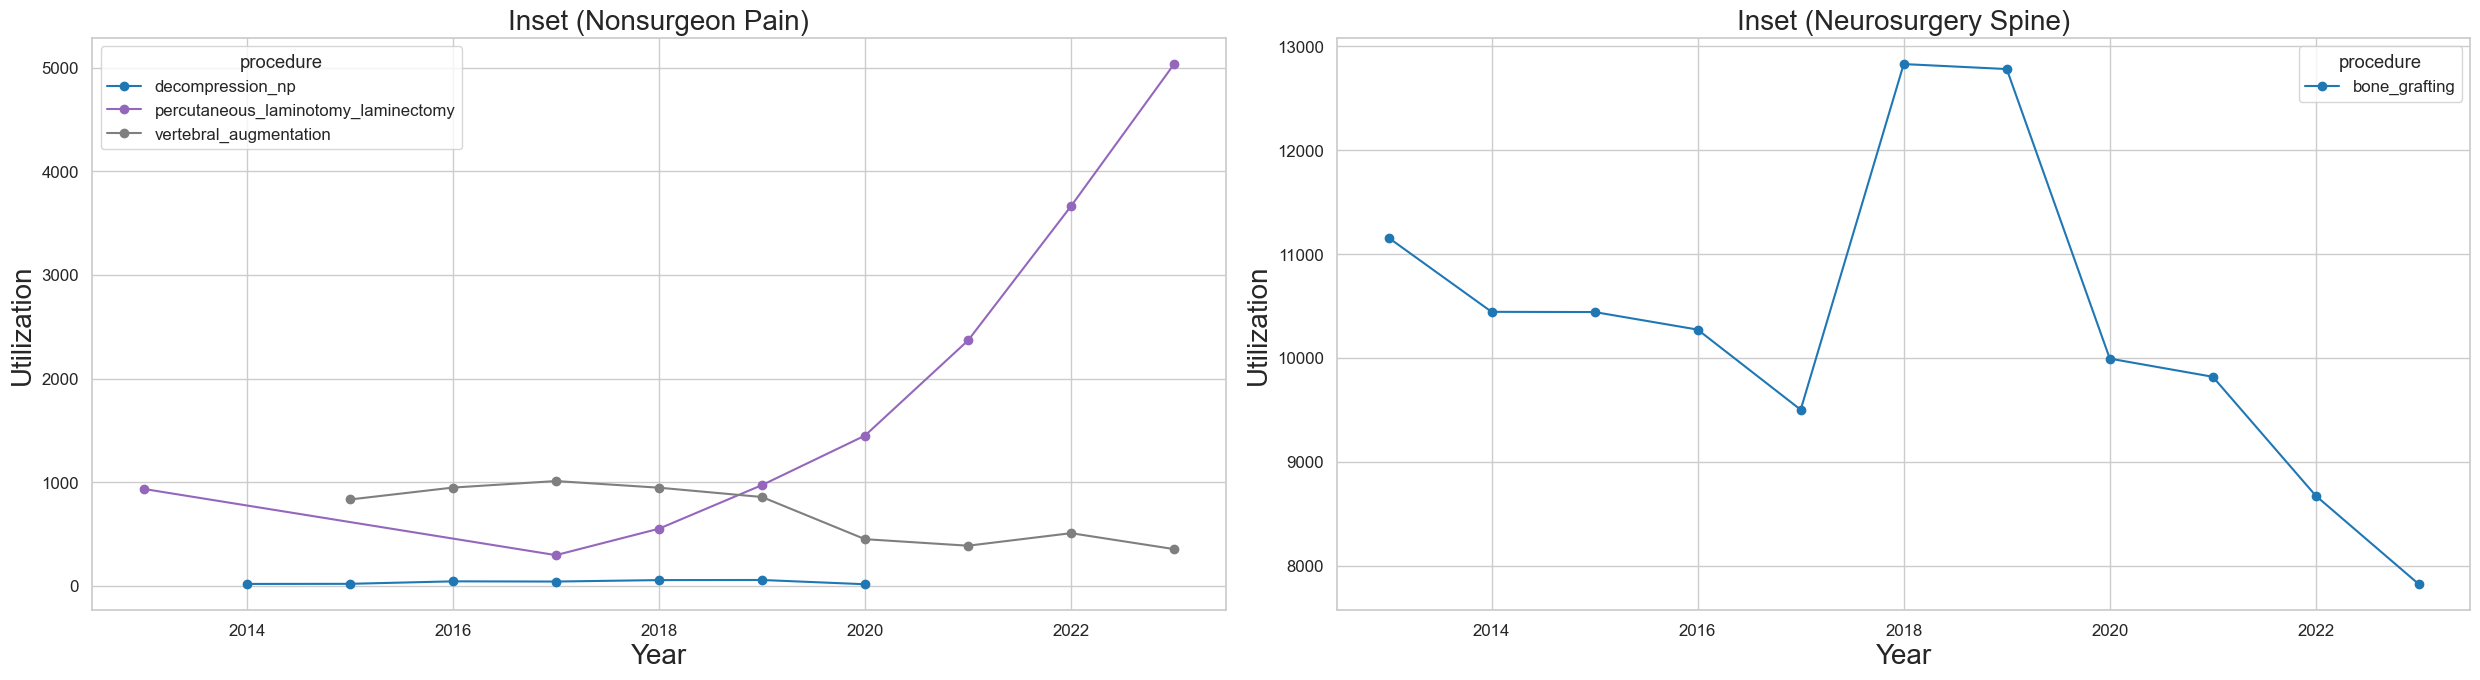

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 
for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('vertebral_augmentation', 'decompression_np', 'percutaneous_laminotomy_laminectomy', 'bone_grafting'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
    
            x = df_sorted['year']
            y = df_sorted['Sum_Utilization']
    
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Utilization", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name_updated[i]})", fontsize=20)

plt.tight_layout()

## Average Standardized Payment

In [27]:
util_2023_2013_adj_nonsurg['CI_lower_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_nonsurg['CI_upper_avg_price_per_service'] = util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Avg_Price_per_service_adj_sem']

util_2023_2013_adj_spine['CI_lower_avg_price_per_service'] = util_2023_2013_adj_spine['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_spine['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_spine['CI_upper_avg_price_per_service'] = util_2023_2013_adj_spine['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_spine['Avg_Price_per_service_adj_sem']

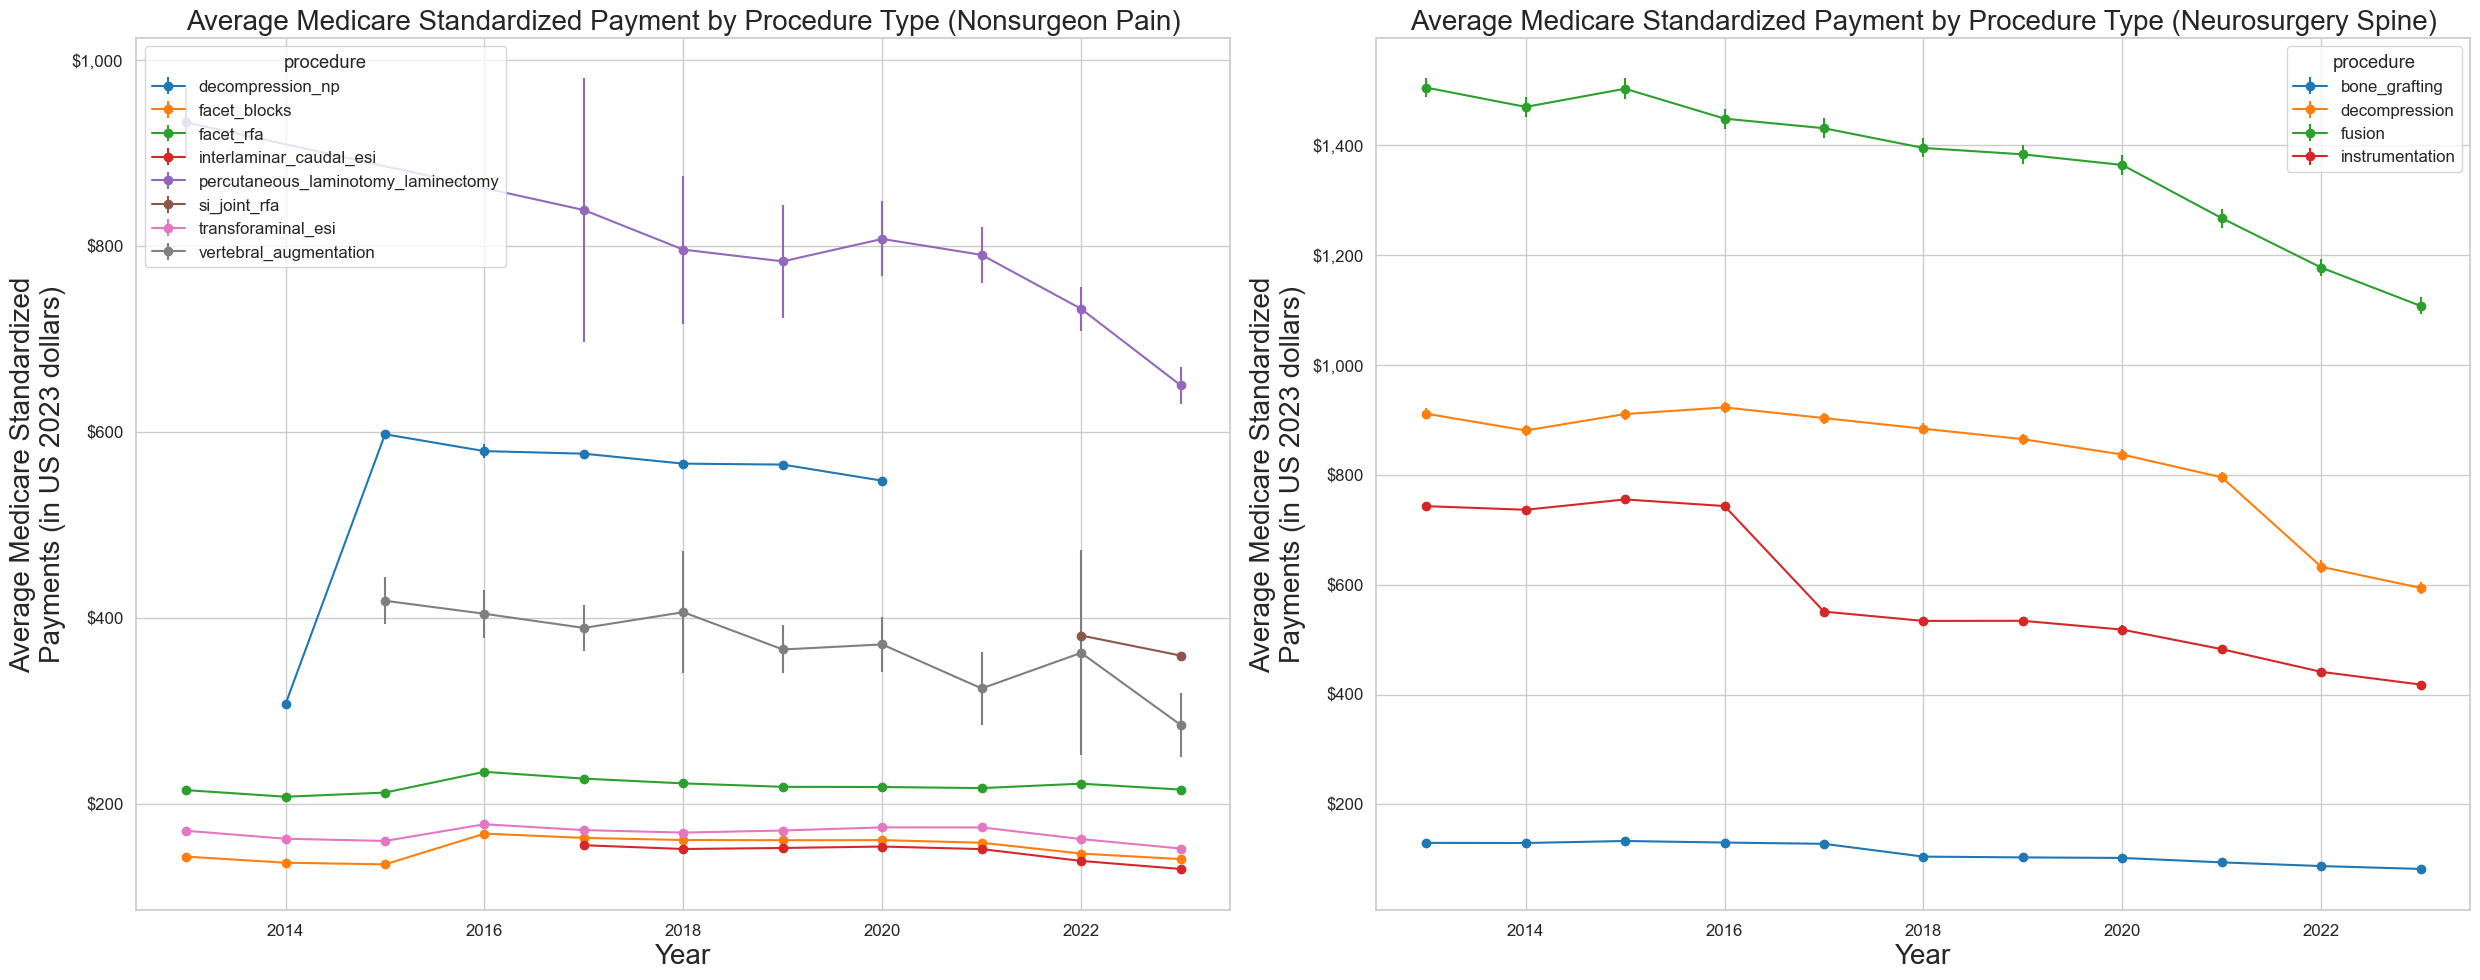

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Avg_Price_per_service_adj']
    
        # Compute error bars from CI bounds
        yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
        axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Average Medicare Standardized Payment by Procedure Type ({specialty_name_updated[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

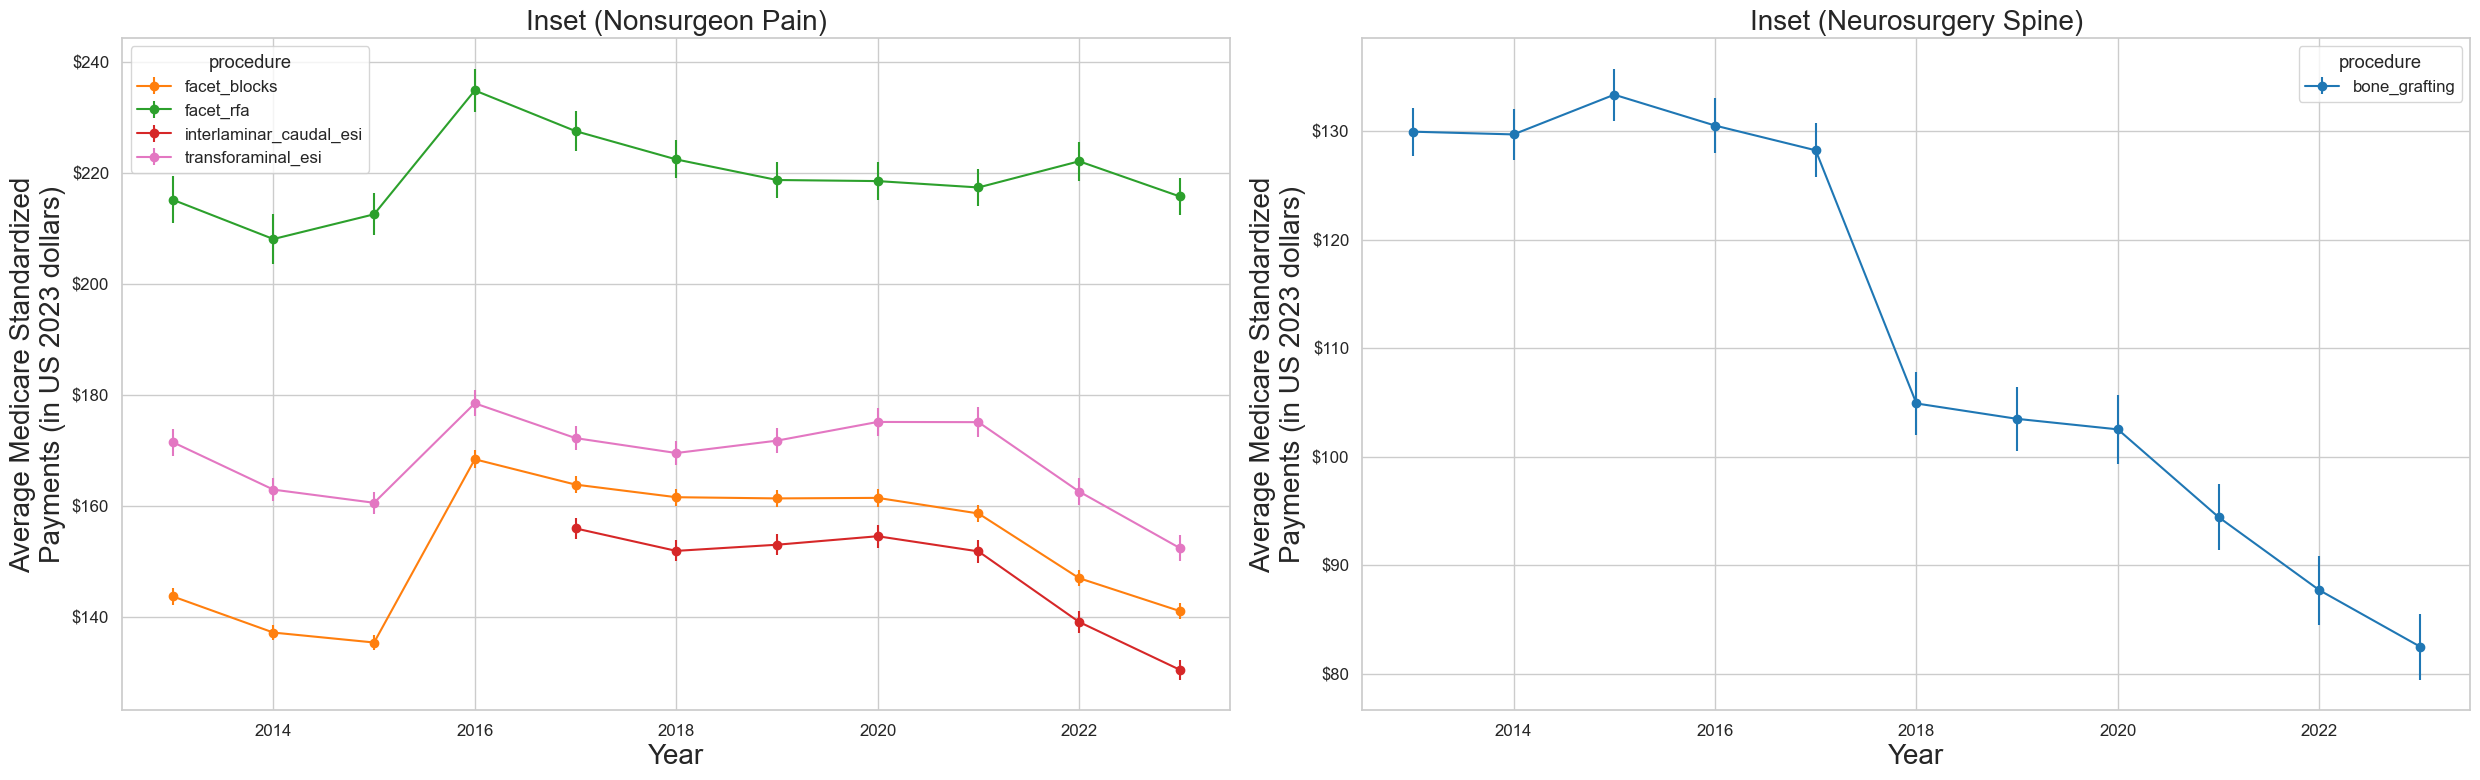

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 
for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('facet_rfa', 'transforaminal_esi', 'facet_blocks', 'interlaminar_caudal_esi', 'bone_grafting'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Avg_Price_per_service_adj']
        
            # Compute error bars from CI bounds
            yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
            axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name_updated[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Average Standardized Payment Growth Rate

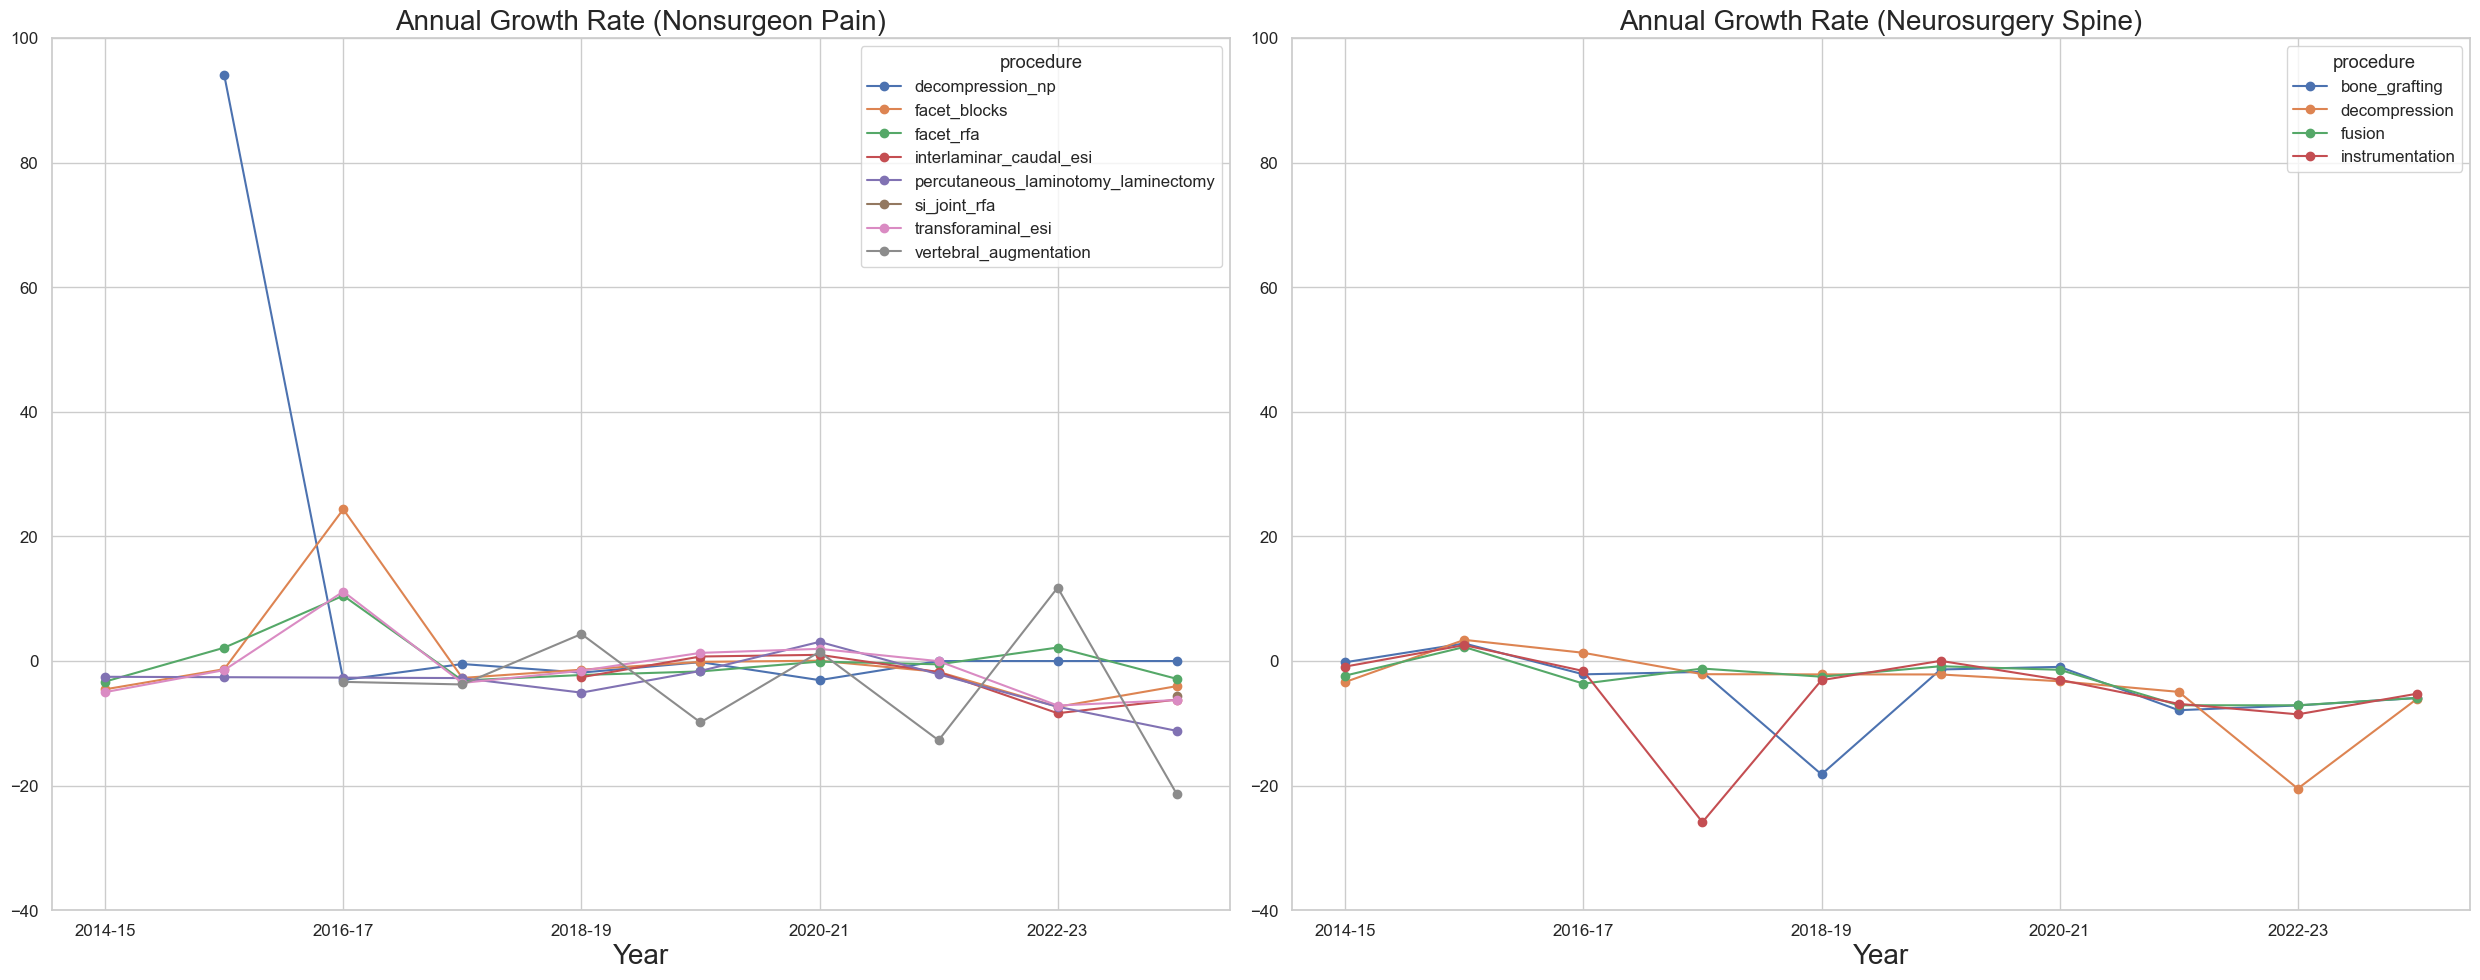

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}
aagr_no_interp = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}
all_deltas = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name_updated[i]].append([label, np.nanmean(delta), specialty_name_updated[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name_updated[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name_updated[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylim([-40, 100])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name_updated[i]})", fontsize=20)

plt.tight_layout()

In [42]:
pd.DataFrame(
    aagr['Nonsurgeon Pain'] + aagr['Neurosurgery Spine'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_vs_spine_aagr_by_procedure.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_76099/3845192170.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


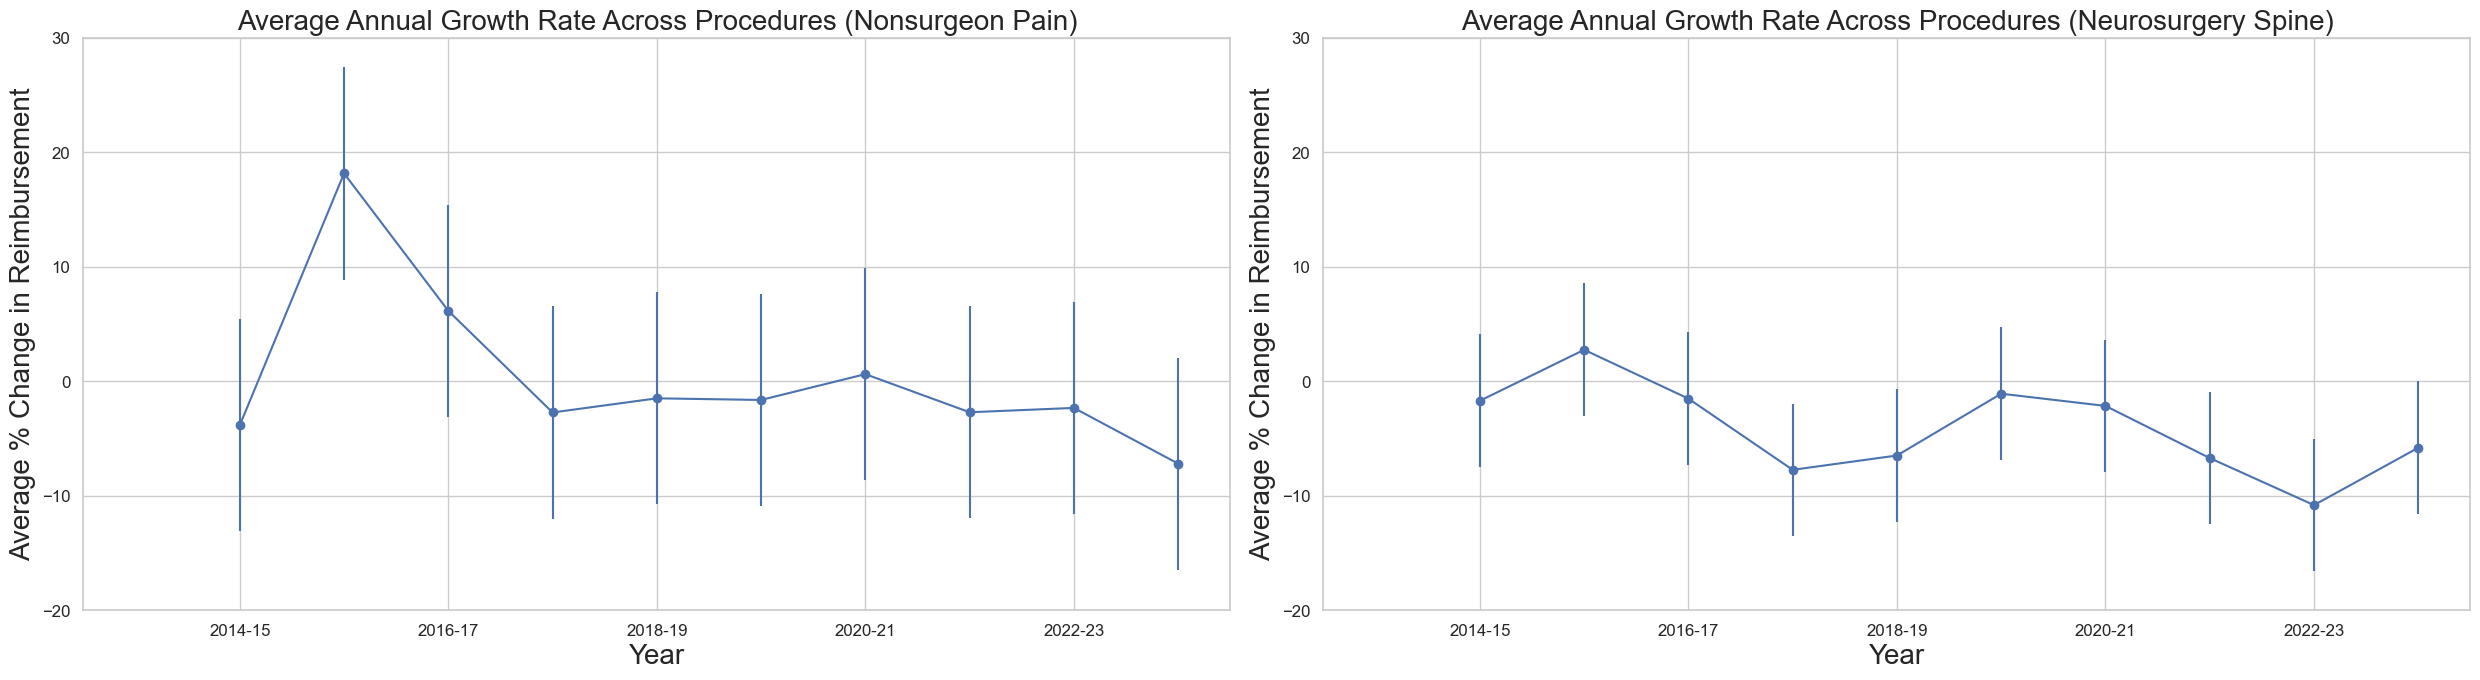

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement", fontsize=20)
    axs[i].set_ylim([-20, 30])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name_updated[i]})", fontsize=20)

    i += 1

plt.tight_layout()

## Total Payment

In [44]:
util_2023_2013_adj_nonsurg['CI_lower_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']
util_2023_2013_adj_nonsurg['CI_upper_tot_pymt'] = util_2023_2013_adj_nonsurg['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_nonsurg['Tot_Pymt_adj_sem']

util_2023_2013_adj_spine['CI_lower_tot_pymt'] = util_2023_2013_adj_spine['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_spine['Tot_Pymt_adj_sem']
util_2023_2013_adj_spine['CI_upper_tot_pymt'] = util_2023_2013_adj_spine['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_spine['Tot_Pymt_adj_sem']

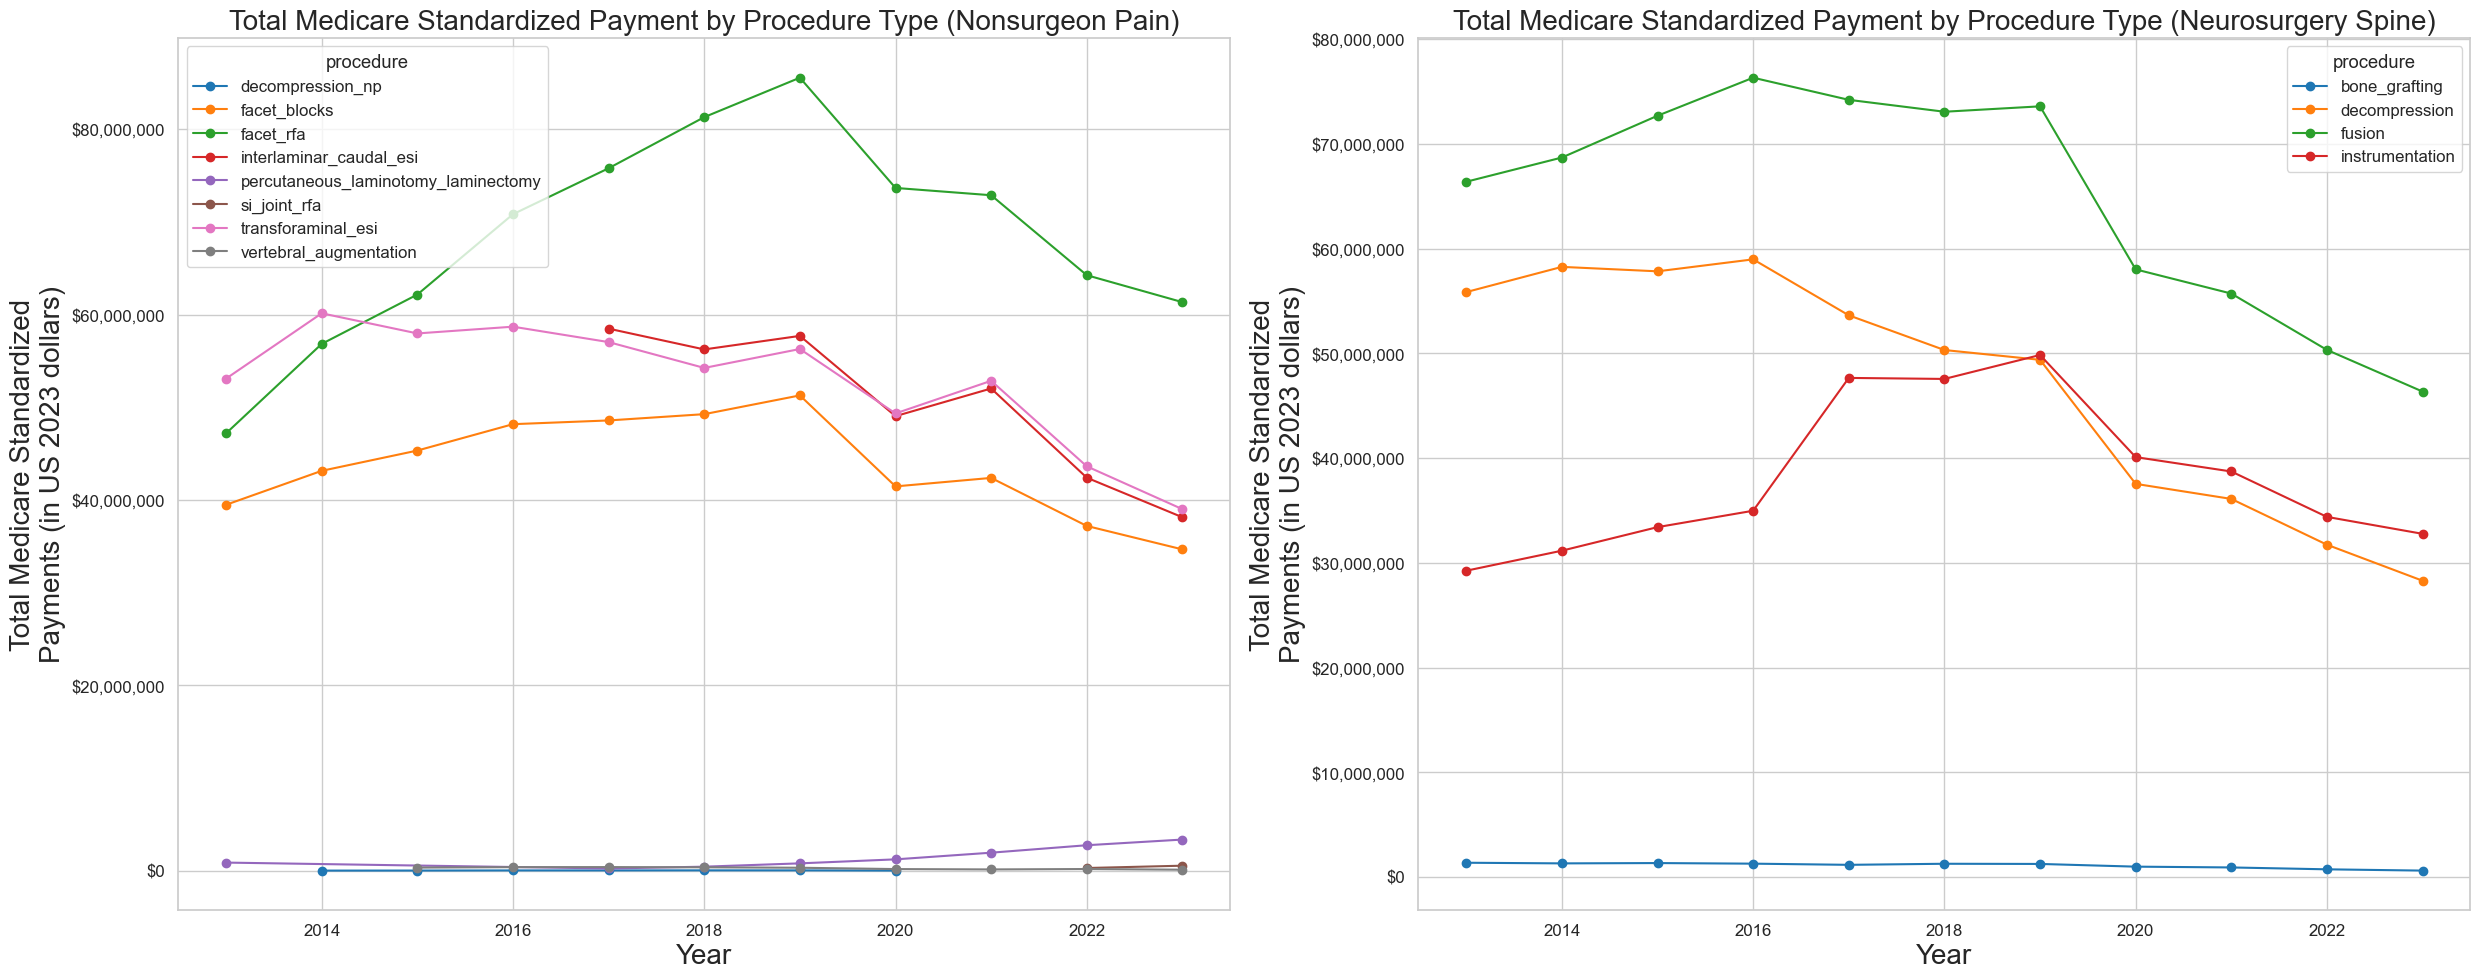

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0

    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Sum_Pymt_adj']
    
        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Total Medicare Standardized Payment by Procedure Type ({specialty_name_updated[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

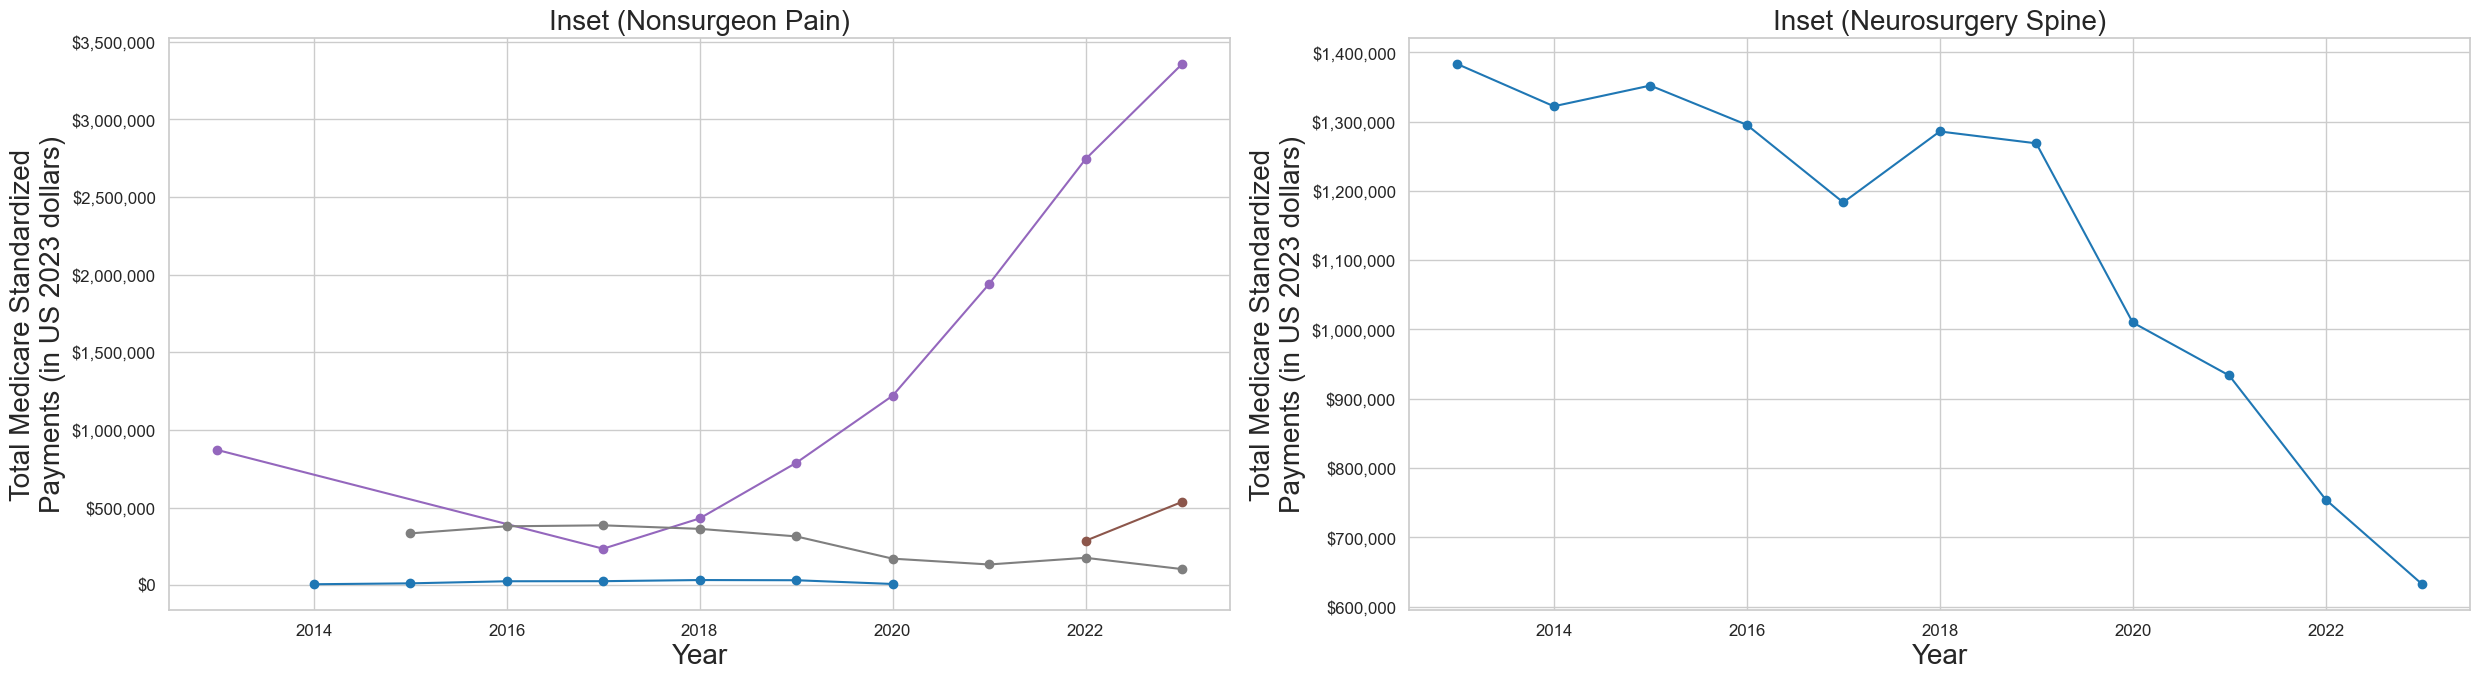

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in ('decompression_np', 'percutaneous_laminotomy_laminectomy', 'vertebral_augmentation', 'si_joint_rfa', 'bone_grafting'):
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Sum_Pymt_adj']
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        
        p_num += 1
    
    # axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name_updated[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Total Payment Growth Rate

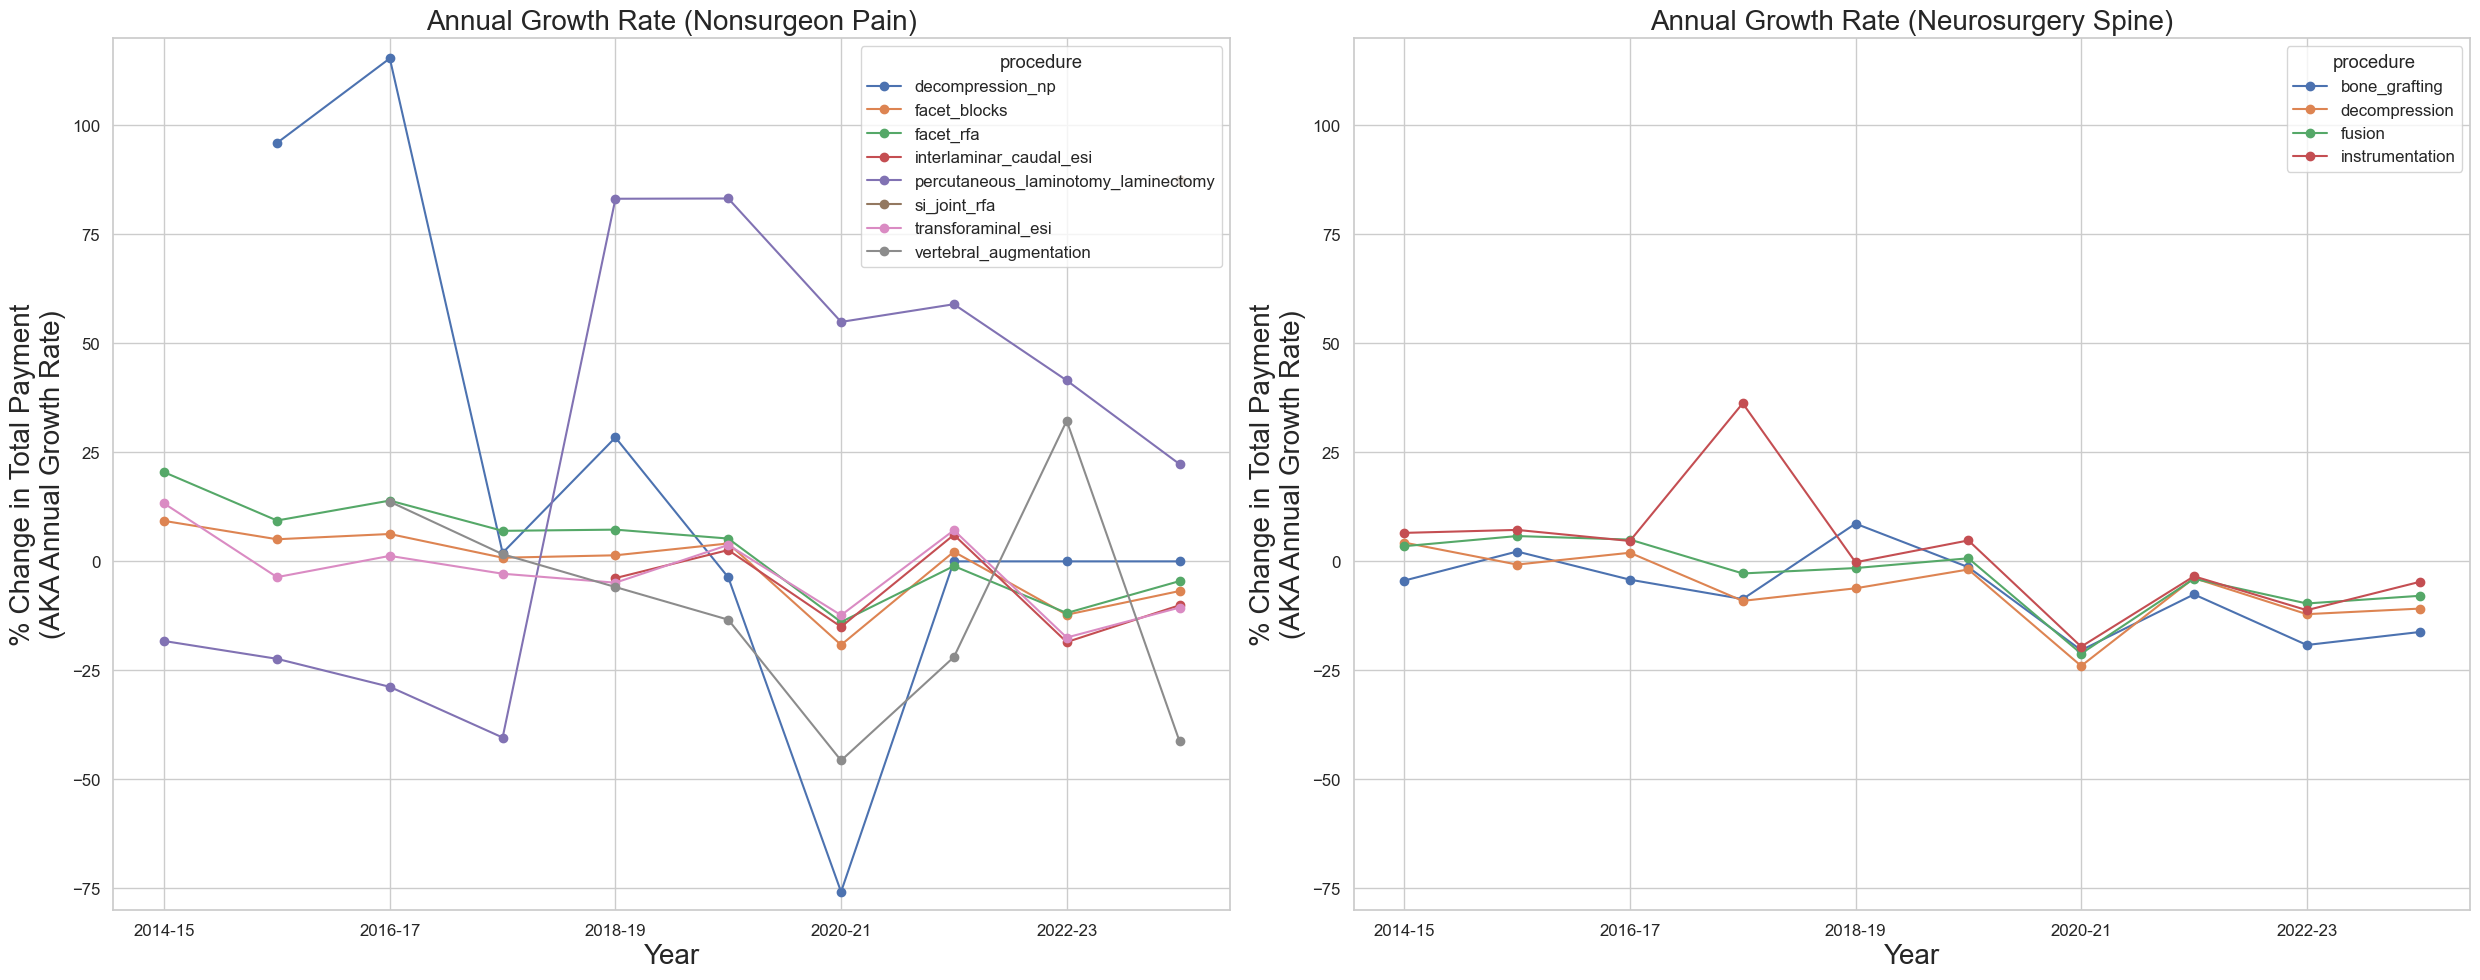

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}
aagr_no_interp = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}
all_deltas = {'Nonsurgeon Pain': [], 'Neurosurgery Spine': []}

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name_updated[i]].append([label, np.nanmean(delta), specialty_name_updated[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name_updated[i]].append([label, np.nanmean(delta_no_interp), specialty_name_updated[i]])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name_updated[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)", fontsize=20)
    axs[i].set_ylim([-80, 120])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name_updated[i]})", fontsize=20)

plt.tight_layout()

In [49]:
pd.DataFrame(
    aagr['Nonsurgeon Pain'] + aagr['Neurosurgery Spine'], columns=['procedure', 'AAGR (%)', 'specialty']
).sort_values(by=['AAGR (%)']).to_csv("results/pain_vs_spine_total_pymt_aagr_by_procedure.csv", index=False)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_76099/182460637.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


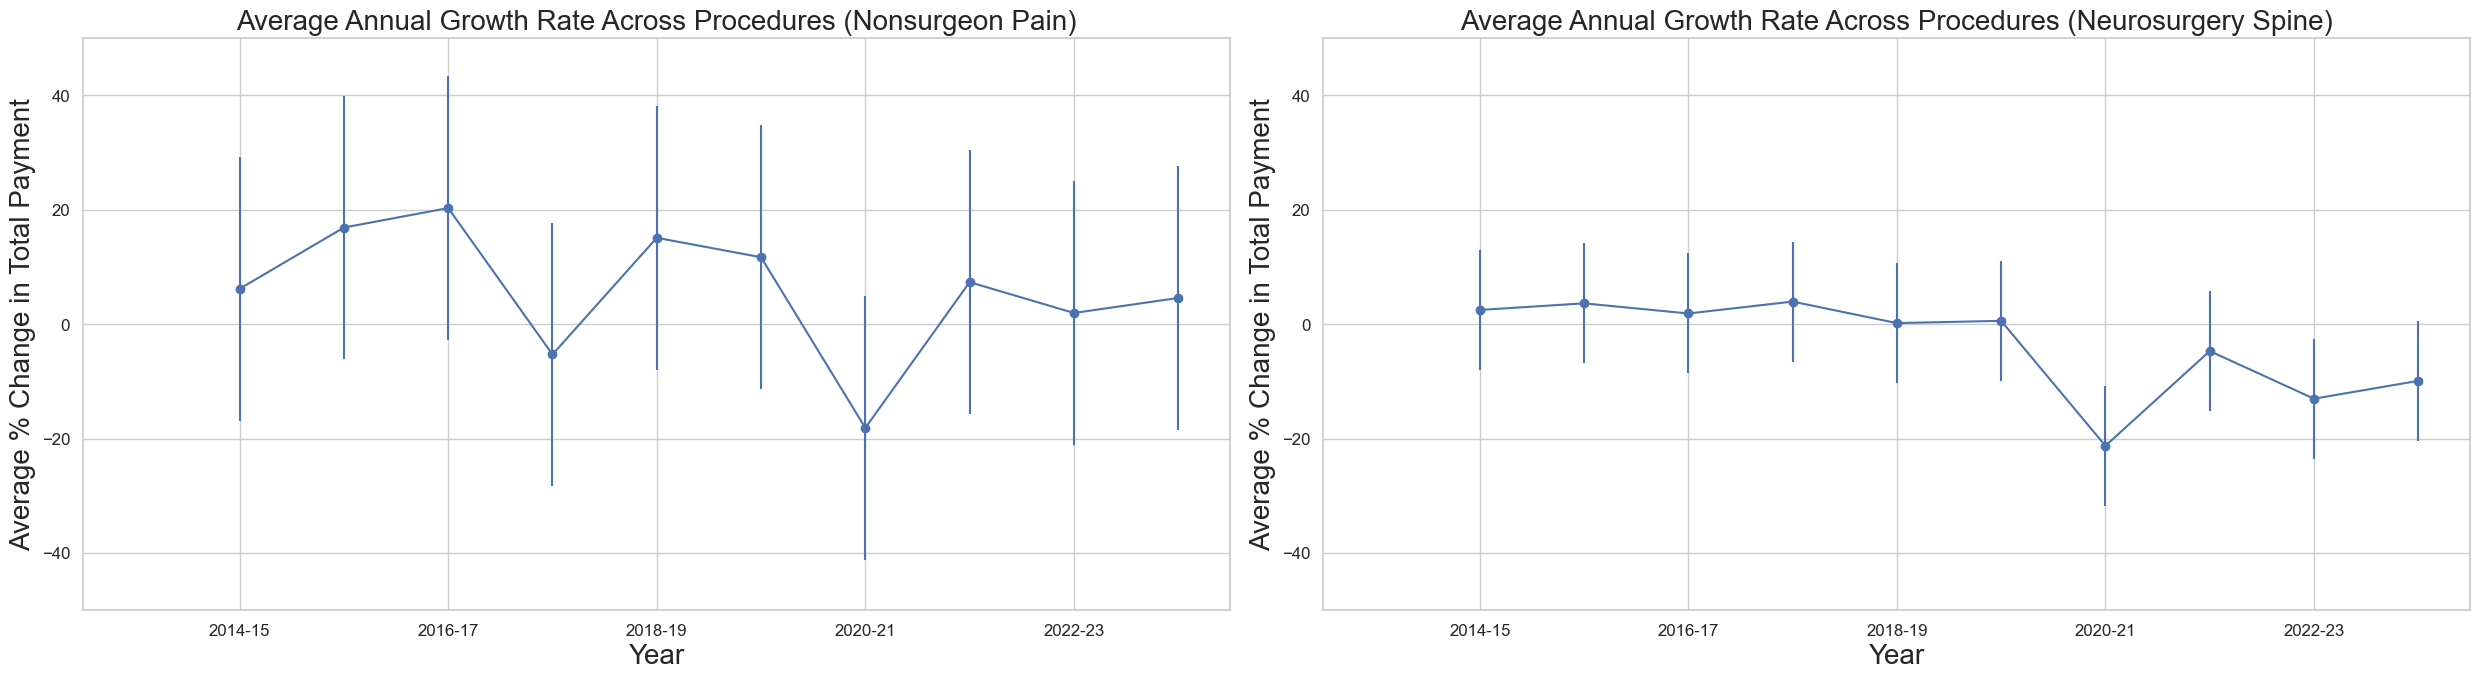

In [50]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment", fontsize=20)
    axs[i].set_ylim([-50, 50])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name_updated[i]})", fontsize=20)

    i += 1

plt.tight_layout()

# Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [24]:
def sklearn_linear_pvalues(model, X, y):
    """
    Compute OLS-style SEs, t-stats, and p-values for a fitted sklearn LinearRegression.
    Works only for unregularized linear models (no Ridge/Lasso).

    Parameters
    ----------
    model : sklearn.linear_model.LinearRegression (already .fit())
    X : pandas.DataFrame or numpy array (the SAME features the model was fit on)
    y : pandas Series or numpy array (target used for fitting)

    Returns
    -------
    pandas.DataFrame with columns: term, coef, se, t, p
    """
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float).ravel()

    # Build design matrix (add intercept column if model has an intercept)
    if getattr(model, "fit_intercept", False):
        X_design = np.column_stack([np.ones(X_arr.shape[0]), X_arr])
        coef = np.r_[model.intercept_, model.coef_]
        names = ["Intercept"] + (list(X.columns) if hasattr(X, "columns") else [f"x{i}" for i in range(X_arr.shape[1])])
    else:
        X_design = X_arr
        coef = np.asarray(model.coef_).ravel()
        names = list(X.columns) if hasattr(X, "columns") else [f"x{i}" for i in range(X_arr.shape[1])]

    # Predictions & residuals
    y_hat = X_design @ coef
    resid = y_arr - y_hat

    n, p = X_design.shape
    dof = n - p
    if dof <= 0:
        raise ValueError("Not enough degrees of freedom to compute standard errors (n <= p).")

    # Residual variance (sigma^2) and covariance of coefficients
    sigma2 = (resid @ resid) / dof
    # Use pinv to be robust to near-collinearity
    XtX_inv = np.linalg.pinv(X_design.T @ X_design)
    cov = sigma2 * XtX_inv

    se = np.sqrt(np.diag(cov))
    t_stats = coef / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    return pd.DataFrame({"term": names, "coef": coef, "se": se, "t": t_stats, "p": p_vals})


## Linear Regression by Procedure

In [31]:
specialty_name = ["Nonsurgeon Pain", "Neurosurgery Spine"]
aagr = {'Nonsurgeon Pain': {}, 'Neurosurgery Spine': {}}
aagr_no_interp = {'Nonsurgeon Pain': {}, 'Neurosurgery Spine': {}}

x_years = list(range(2020, 2024)) # list(range(2013, 2024))

for i, specialty in enumerate([util_2023_2013_adj_nonsurg, util_2023_2013_adj_spine]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[k]: item for k, item in enumerate(y)}
        x_new = x_years
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy()  * 100
        
        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]][label] = delta

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]][label] = delta_no_interp

In [32]:
aagr_for_df = []
years = x_years
for specialty, data in aagr.items():
    for proc, delta in data.items():
        aagr_for_df.extend([[years[i], proc, delta[i]] for i in range(len(delta))])

aagr_df = pd.DataFrame(aagr_for_df, columns=["year", "procedure", "Avg_Price_per_service_change"])

aagr_df_nonsurg = util_2023_2013_adj_nonsurg.merge(aagr_df, on=["procedure", "year"])
aagr_df_spine = util_2023_2013_adj_spine.merge(aagr_df, on=["procedure", "year"])

In [33]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'Avg_Price_per_service_change']]
spine_data_for_regression = pd.get_dummies(spine_data_for_regression, columns=['procedure'])
# spine_data_for_regression['specialty'] = 0

nonsurg_data_for_regression = aagr_df_nonsurg[['procedure', 'year', 'Avg_Price_per_service_change']]
nonsurg_data_for_regression = pd.get_dummies(nonsurg_data_for_regression, columns=['procedure'])
# neurovasc_data_for_regression['specialty'] = 1

In [34]:
all_regression_data = pd.concat([nonsurg_data_for_regression, spine_data_for_regression]).reset_index(drop=True)
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_change'])

In [35]:
X = all_regression_data.drop(columns=['Avg_Price_per_service_change']).fillna(False)
y = all_regression_data['Avg_Price_per_service_change']

In [36]:
model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.8f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by='coef')

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_81849/1555789074.py:44: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(cov))


,term,coef,p
11,procedure_decompression,-4.661460e+00,0.98606006
9,procedure_vertebral_augmentation,-1.578922e+00,0.99527805
1,year,-1.468433e+00,0.35999314
10,procedure_bone_grafting,-1.139930e+00,0.99659090
13,procedure_instrumentation,-1.048205e+00,0.99686521
6,procedure_percutaneous_laminotomy_laminectomy,-1.046521e+00,0.99687025
12,procedure_fusion,-8.666174e-01,0.99740827
2,procedure_decompression_np,-8.881784e-16,nan
5,procedure_interlaminar_caudal_esi,4.004781e-01,0.99880232
8,procedure_transforaminal_esi,1.369384e+00,0.99590469


In [37]:
summary[['term', 'coef', 'p']].to_csv("results/pain_nonsurg_vs_spine_regression_procedure_postcovid.csv", index=False)

In [38]:
nonsurg_data_for_regression = aagr_df_nonsurg[['procedure', 'year', 'Avg_Price_per_service_change']]
nonsurg_data_for_regression['specialty'] = 0

spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'Avg_Price_per_service_change']]
spine_data_for_regression['specialty'] = 1

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_81849/534058599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonsurg_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_81849/534058599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 1


In [39]:
all_regression_data = pd.concat([nonsurg_data_for_regression, spine_data_for_regression]).reset_index(drop=True)
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_change'])

In [40]:
X = all_regression_data.drop(columns=['Avg_Price_per_service_change', 'procedure']).fillna(False)
y = all_regression_data['Avg_Price_per_service_change']

In [41]:
model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.8f}'.format(x)) 
summary[['term', 'coef', 'p']]

,term,coef,p
0,Intercept,2904.714190,0.26919872
1,year,-1.438929,0.26841325
2,specialty,-2.970957,0.17827214
